<a href="https://colab.research.google.com/github/Dimas-091206/regresilinear_kelas5b_kelompok5/blob/main/RegresiLinear_Kelas5B_Kelompok5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# 1. Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [19]:
# 2. Memuat Dataset Life Expectancy (WHO) & Pembersihan Awal
# Unggah file 'Life Expectancy Data.csv' (atau ZIP-nya) ke Google Colab bila belum ada di folder kerja
import os
NAMA_FILE = 'Life Expectancy Data.csv'

if not os.path.exists(NAMA_FILE):
    from google.colab import files
    import zipfile
    print("Silakan unggah file CSV atau ZIP dataset...")
    for nama in files.upload():
        if nama.lower().endswith('.zip'):
            zipfile.ZipFile(nama).extractall('.')

df = pd.read_csv(NAMA_FILE)
print(f"Dataset berhasil dimuat. Jumlah baris awal: {len(df)}")

# Membersihkan nama kolom: hapus spasi di awal/akhir dan rapikan spasi ganda
# (contoh: 'Life expectancy ' -> 'Life expectancy', ' BMI ' -> 'BMI')
df.columns = df.columns.str.strip().str.replace(r'\s+', ' ', regex=True)
print("Nama kolom berhasil dirapikan.")

Dataset berhasil dimuat. Jumlah baris awal: 2938
Nama kolom berhasil dirapikan.


In [20]:
# 3. Melihat Data Awal
display(df.head())

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [21]:
# 4. Informasi Dataset
print(f"Dimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.info()

Dimensi dataset: 2938 baris, 22 kolom
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-nu

In [22]:
# 5. Daftar Nama Kolom
print(df.columns.tolist())

['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness 1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [23]:
# 6. Melihat Data Akhir
display(df.tail())

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.0,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.0,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.0,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.0,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8
2937,Zimbabwe,2000,Developing,46.0,665.0,24,1.68,0.0,79.0,1483,...,78.0,7.10,78.0,43.5,547.358878,12222251.0,11.0,11.2,0.434,9.8


## Inspeksi Awal Data (Initial Data Inspection)

### Tujuan Skrip

Notebook ini bertujuan melakukan Exploratory Data Analysis (EDA), preprocessing, dan pemodelan regresi linear pada dataset **Life Expectancy (WHO)**.

Tahapan analisis yang dilakukan:

1. Memuat dataset `Life Expectancy Data.csv` dan merapikan nama kolom.
2. Melakukan inspeksi awal terhadap jumlah baris, kolom, tipe data, dan isi dataset.
3. Mengecek kualitas data, meliputi missing values dan data duplikat.
4. Menampilkan statistik deskriptif untuk variabel numerik dan kategorikal.
5. Melakukan analisis univariat menggunakan histogram, boxplot, dan countplot.
6. Melakukan analisis bivariat dan multivariat menggunakan korelasi, scatter plot, dan boxplot berdasarkan kategori.
7. Melakukan preprocessing: penanganan missing values, encoding, deteksi multikolinearitas (VIF), dan transformasi data.
8. Membuat model regresi linear untuk memprediksi `Life expectancy` (harapan hidup) dan mengevaluasinya dengan MSE, RMSE, dan R².

In [24]:
# Tampilkan 5 baris pertama
print("--- 5 Baris Pertama Data ---")
display(df.head())

# Tampilkan 5 baris terakhir
print("\n--- 5 Baris Terakhir Data ---")
display(df.tail())

# Dimensi data
print(f"\nDimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

# Informasi dataset
print("\n--- Informasi Dataset ---")
df.info()

# Nama kolom
print("\n--- Daftar Nama Kolom ---")
print(df.columns.tolist())

--- 5 Baris Pertama Data ---


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5



--- 5 Baris Terakhir Data ---


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.0,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.0,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.0,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.0,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8
2937,Zimbabwe,2000,Developing,46.0,665.0,24,1.68,0.0,79.0,1483,...,78.0,7.10,78.0,43.5,547.358878,12222251.0,11.0,11.2,0.434,9.8



Dimensi dataset: 2938 baris, 22 kolom

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five death

## Penjelasan Bagian-bagian Penting Skrip

1. **Memuat Dataset**: `pd.read_csv('Life Expectancy Data.csv')` digunakan untuk membaca dataset ke dalam Pandas DataFrame.
2. **Merapikan Nama Kolom**: beberapa nama kolom pada file asli memiliki spasi tersembunyi (misalnya `'Life expectancy '` dan `' BMI '`) yang dapat menyebabkan `KeyError`, sehingga dirapikan dengan `str.strip()` dan `str.replace()`.
3. **Inspeksi Data**: `head()`, `tail()`, `shape`, `info()`, dan `columns` digunakan untuk memahami struktur awal dataset.
4. **Pengecekan Kualitas Data**: dilakukan pemeriksaan terhadap missing values dan data duplikat sebelum analisis lebih lanjut.
5. **Analisis Deskriptif**: digunakan untuk melihat karakteristik umum variabel numerik dan kategorikal.
6. **Visualisasi EDA**: histogram, boxplot, countplot, heatmap, dan scatter plot digunakan untuk melihat distribusi serta hubungan antarvariabel.
7. **Preprocessing & Regresi**: missing values diimputasi, multikolinearitas ditangani berdasarkan VIF, kemudian model `LinearRegression` dilatih dan dievaluasi.

## **Pengecekan Kualitas Data Dasar** (Basic Data Quality Checks)

--- Pengecekan Missing Values ---


,Jumlah Missing,Persentase (%)
Population,652,22.19
Hepatitis B,553,18.82
GDP,448,15.25
Total expenditure,226,7.69
Alcohol,194,6.60
Income composition of resources,167,5.68
Schooling,163,5.55
thinness 5-9 years,34,1.16
thinness 1-19 years,34,1.16
BMI,34,1.16


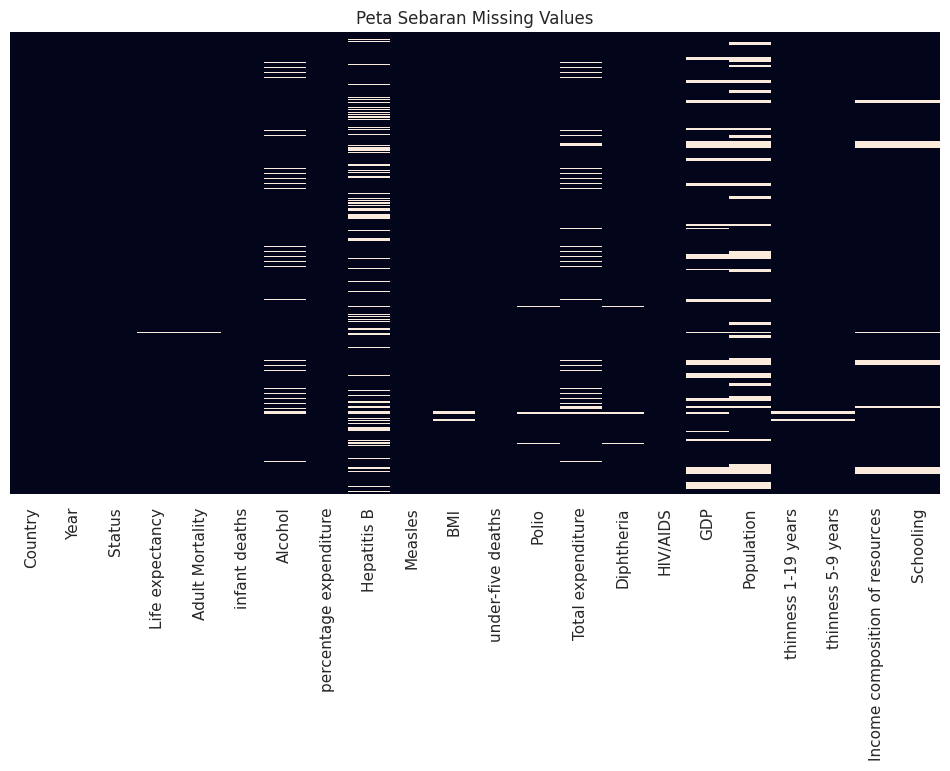

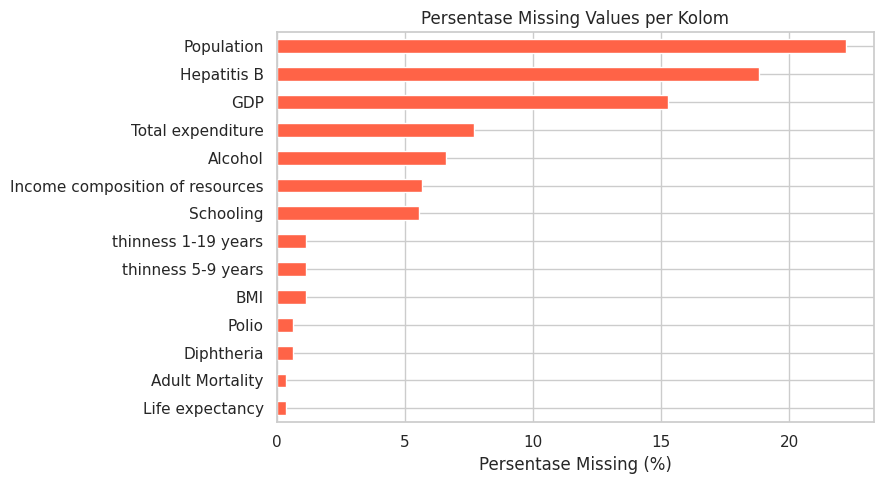


--- Pengecekan Data Duplikat ---
Jumlah baris duplikat identik: 0


In [25]:
print("--- Pengecekan Missing Values ---")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_table = pd.concat(
    [missing_data, missing_percent],
    axis=1,
    keys=['Jumlah Missing', 'Persentase (%)']
)

# Tampilkan hanya kolom yang memiliki missing value, urut dari yang terbanyak
display(missing_table[missing_table['Jumlah Missing'] > 0].sort_values('Persentase (%)', ascending=False).round(2))

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False)
plt.title('Peta Sebaran Missing Values')
plt.show()

plt.figure(figsize=(9, 5))
missing_table[missing_table['Jumlah Missing'] > 0]['Persentase (%)'].sort_values().plot(kind='barh', color='tomato')
plt.xlabel('Persentase Missing (%)')
plt.title('Persentase Missing Values per Kolom')
plt.tight_layout()
plt.show()

print("\n--- Pengecekan Data Duplikat ---")
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat identik: {jumlah_duplikat}")

if jumlah_duplikat > 0:
    print("\nContoh data duplikat:")
    display(df[df.duplicated(keep=False)].head(10))

### Ringkasan Pengecekan Kualitas Data

Hasil pengecekan pada dataset **Life Expectancy (WHO)** menunjukkan:

- Dataset memiliki **2.938 baris** dan **22 kolom** (193 negara, tahun 2000–2015).
- Ditemukan **missing values di 14 kolom**. Kolom dengan missing terbanyak adalah `Population` (±22%), `Hepatitis B` (±19%), `GDP` (±15%), `Total expenditure` (±8%), `Alcohol` (±7%), `Income composition of resources` (±6%), dan `Schooling` (±6%).
- Variabel target `Life expectancy` hanya kehilangan **10 baris (±0,34%)**. Baris ini tidak dapat digunakan untuk melatih model sehingga akan dihapus pada tahap preprocessing.
- **Tidak ditemukan baris duplikat**.
- Karena missing values pada fitur cukup besar, menghapus semua baris yang tidak lengkap akan membuang banyak data. Karena itu penanganannya dilakukan dengan **imputasi** pada tahap preprocessing.

## **Statistik Deskriptif (Descriptive Statistics)**

In [26]:
print("--- Statistik Deskriptif untuk Kolom Numerik ---")
display(df.describe().T.round(2))

print("\n--- Statistik Deskriptif untuk Kolom Kategorikal ---")
display(df.describe(include=['object', 'string']))
print(df['Status'].value_counts())

--- Statistik Deskriptif untuk Kolom Numerik ---


,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2007.52,4.61,2000.00,2004.00,2008.00,2012.00,2.015000e+03
Life expectancy,2928.0,69.22,9.52,36.30,63.10,72.10,75.70,8.900000e+01
Adult Mortality,2928.0,164.80,124.29,1.00,74.00,144.00,228.00,7.230000e+02
infant deaths,2938.0,30.30,117.93,0.00,0.00,3.00,22.00,1.800000e+03
Alcohol,2744.0,4.60,4.05,0.01,0.88,3.76,7.70,1.787000e+01
percentage expenditure,2938.0,738.25,1987.91,0.00,4.69,64.91,441.53,1.947991e+04
Hepatitis B,2385.0,80.94,25.07,1.00,77.00,92.00,97.00,9.900000e+01
Measles,2938.0,2419.59,11467.27,0.00,0.00,17.00,360.25,2.121830e+05
BMI,2904.0,38.32,20.04,1.00,19.30,43.50,56.20,8.730000e+01
under-five deaths,2938.0,42.04,160.45,0.00,0.00,4.00,28.00,2.500000e+03



--- Statistik Deskriptif untuk Kolom Kategorikal ---


,Country,Status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


Status
Developing    2426
Developed      512
Name: count, dtype: int64


### Ringkasan Statistik Deskriptif

Dataset Life Expectancy memiliki variabel numerik seperti `Life expectancy`, `Adult Mortality`, `infant deaths`, `Alcohol`, `GDP`, `Population`, `BMI`, `Schooling`, dan lainnya, serta variabel kategorikal `Country` dan `Status`.

Beberapa hal yang terlihat dari statistik deskriptif:

- `Life expectancy` memiliki rata-rata sekitar **69,2 tahun** dengan rentang **36,3 – 89,0 tahun**. Median (72,1) lebih tinggi dari rata-rata sehingga distribusinya miring ke kiri.
- `Status` memiliki 2 kategori: **Developing** (2.426 baris) dan **Developed** (512 baris), sehingga data didominasi negara berkembang.
- Banyak fitur memiliki **rentang sangat lebar** dan rata-rata jauh di atas median, misalnya `Population` (maks ±1,29 miliar), `GDP`, `Measles`, `infant deaths`, dan `under-five deaths`. Ini menandakan distribusi miring ke kanan dan adanya nilai ekstrem.
- Terdapat nilai yang mencurigakan, misalnya `Schooling` bernilai 0 (28 baris), `Income composition of resources` bernilai 0 (130 baris), dan `infant deaths` bernilai 0 (848 baris). Nilai ini kemungkinan merupakan data yang tidak tercatat.
- Imunisasi (`Polio`, `Diphtheria`, `Hepatitis B`) memiliki median sekitar 92–93%, tetapi nilai minimum sangat rendah.

## **Analisis Univariat (Univariate Analysis)**

### Analisis Univariat untuk Kolom Numerik ###


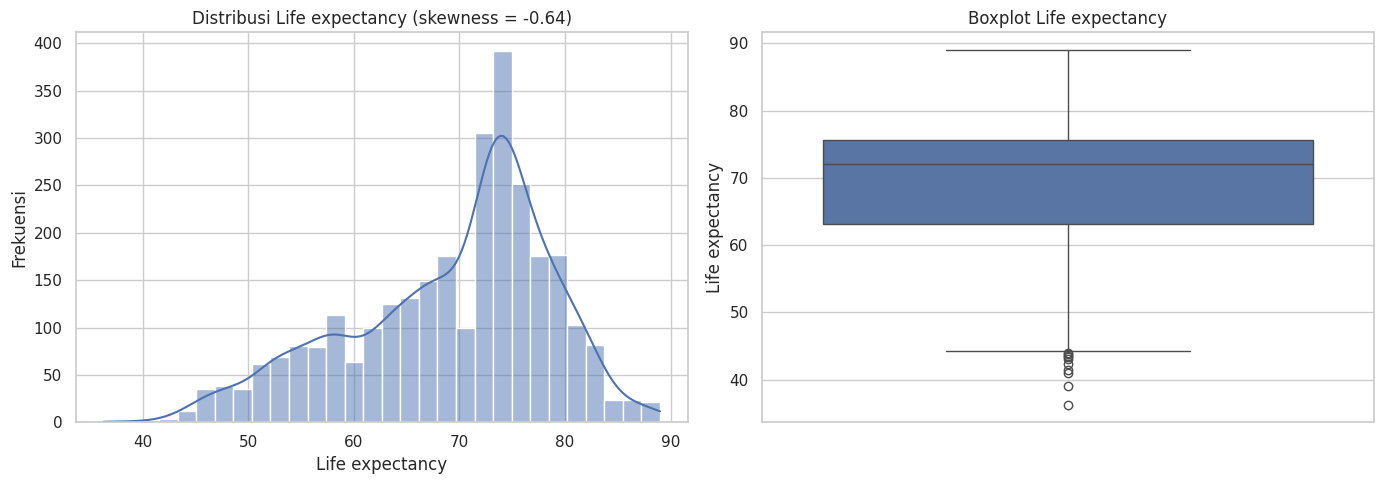

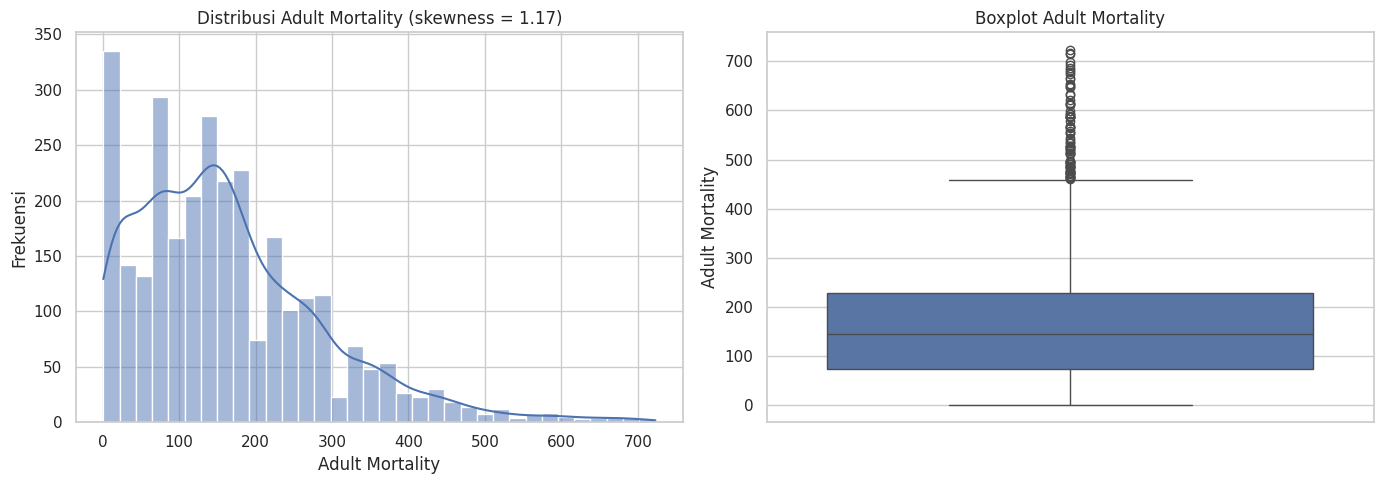

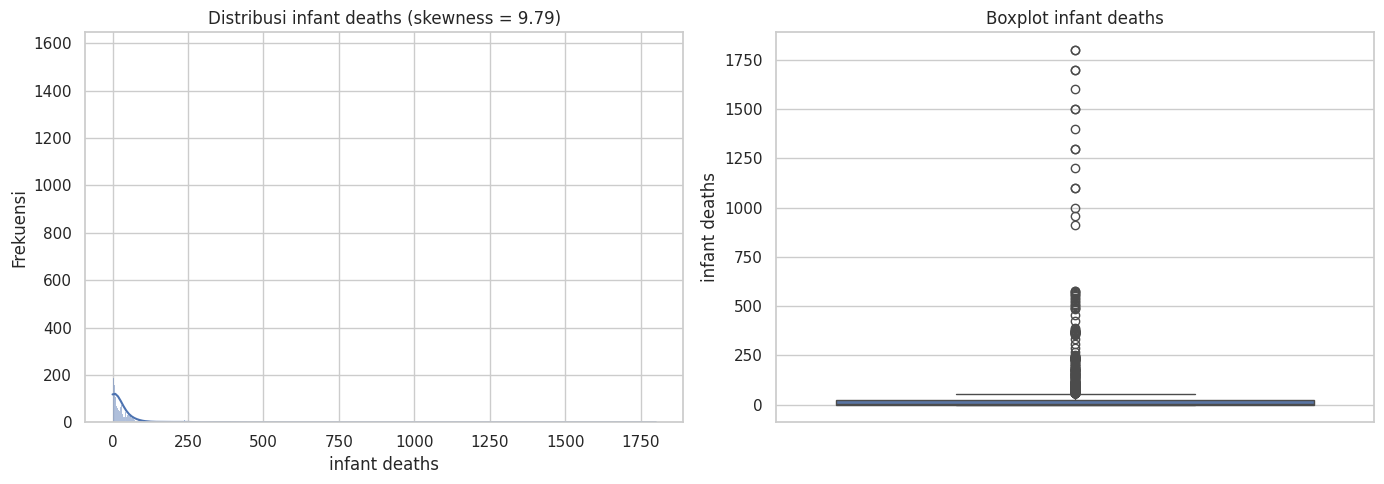

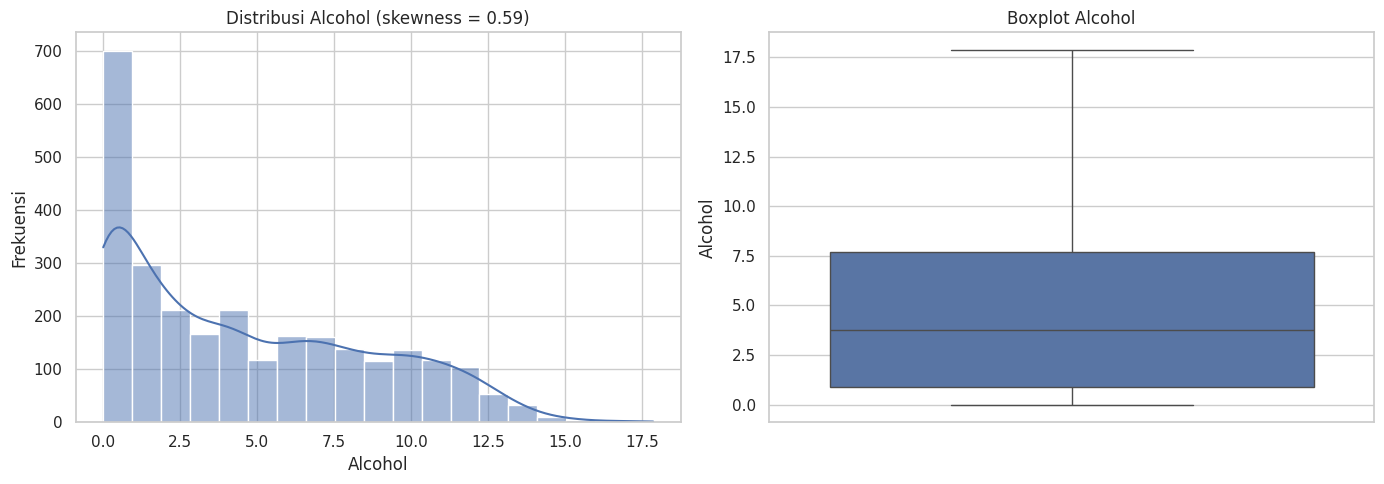

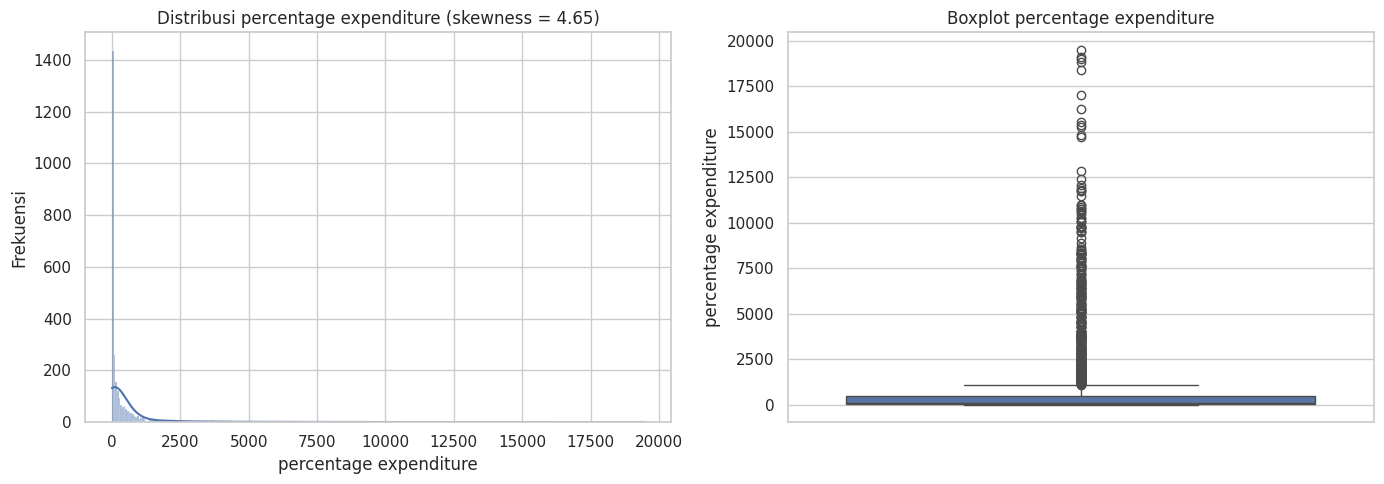

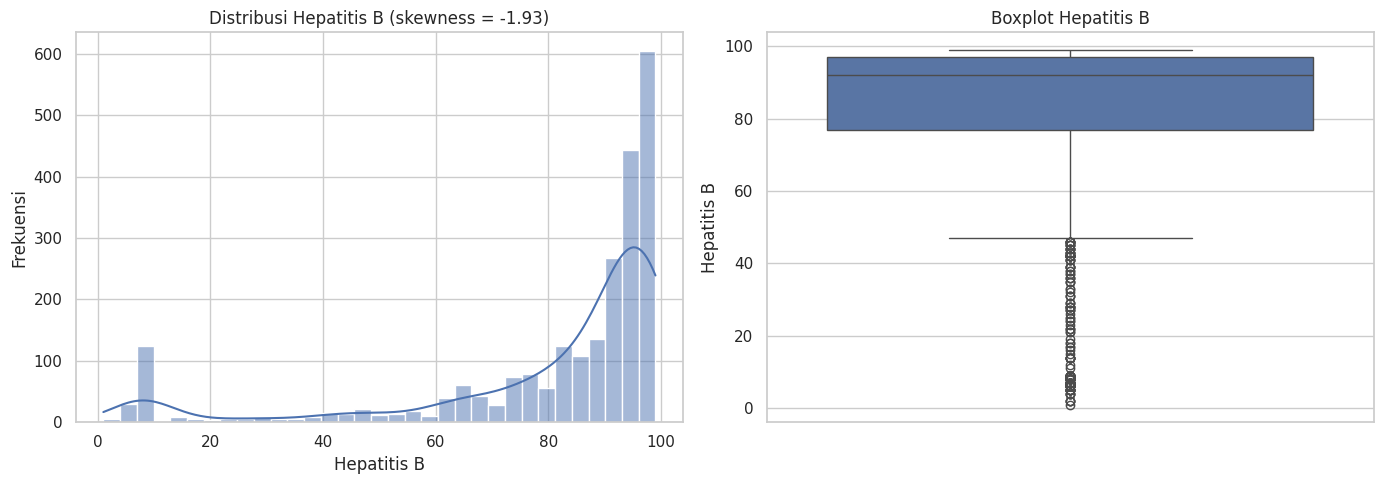

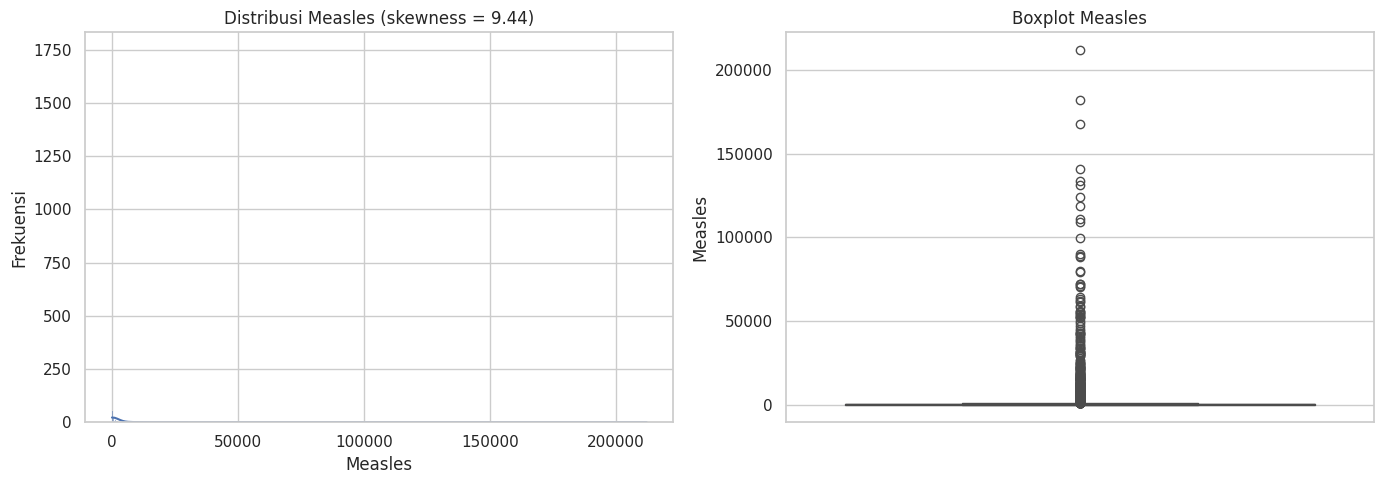

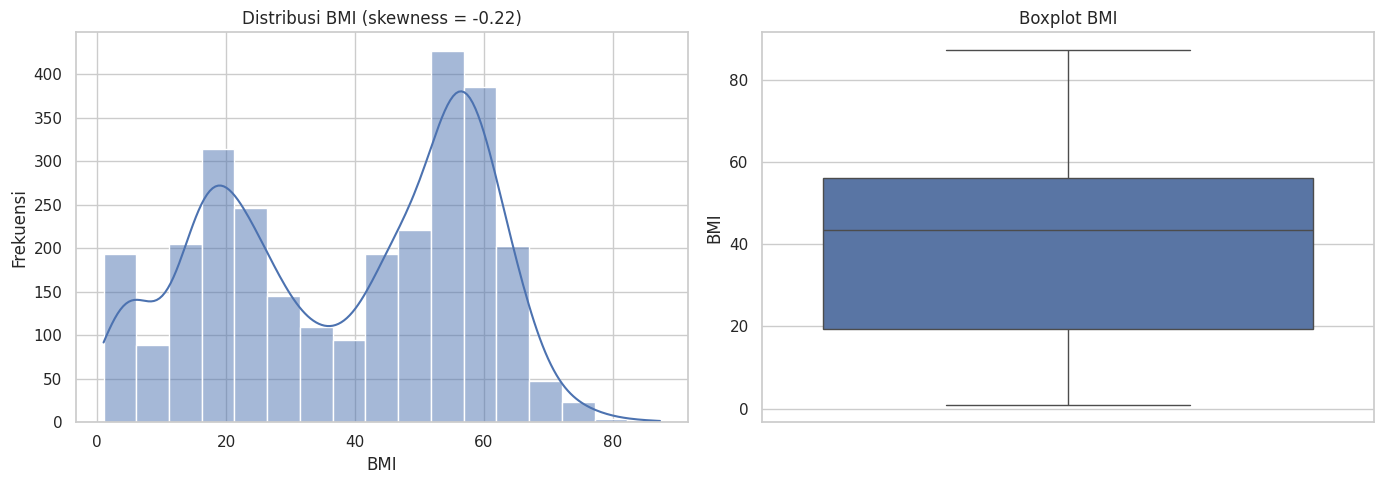

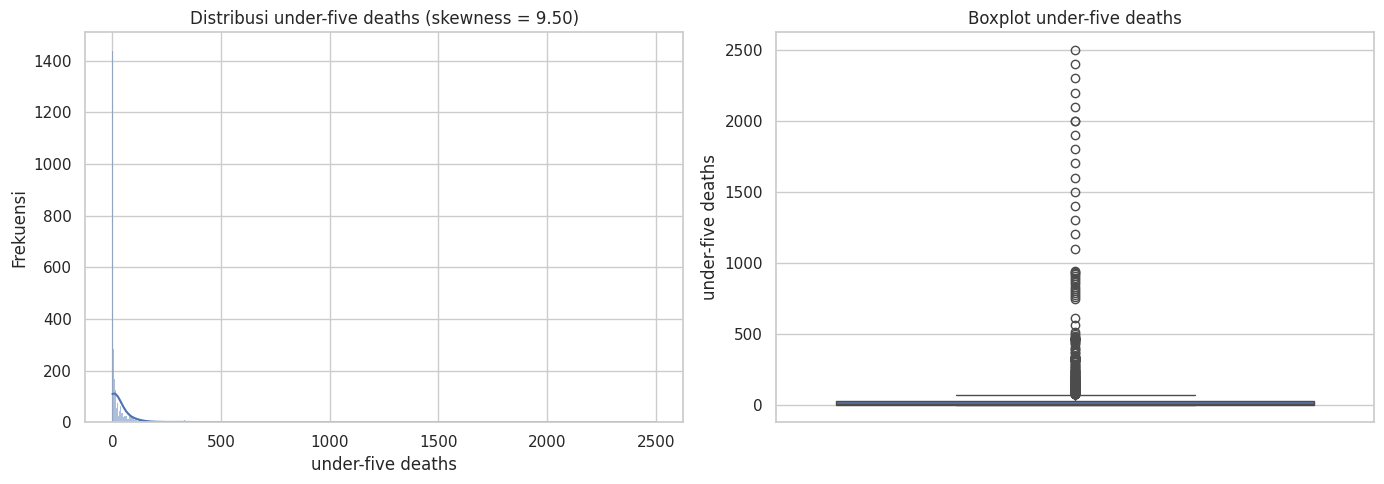

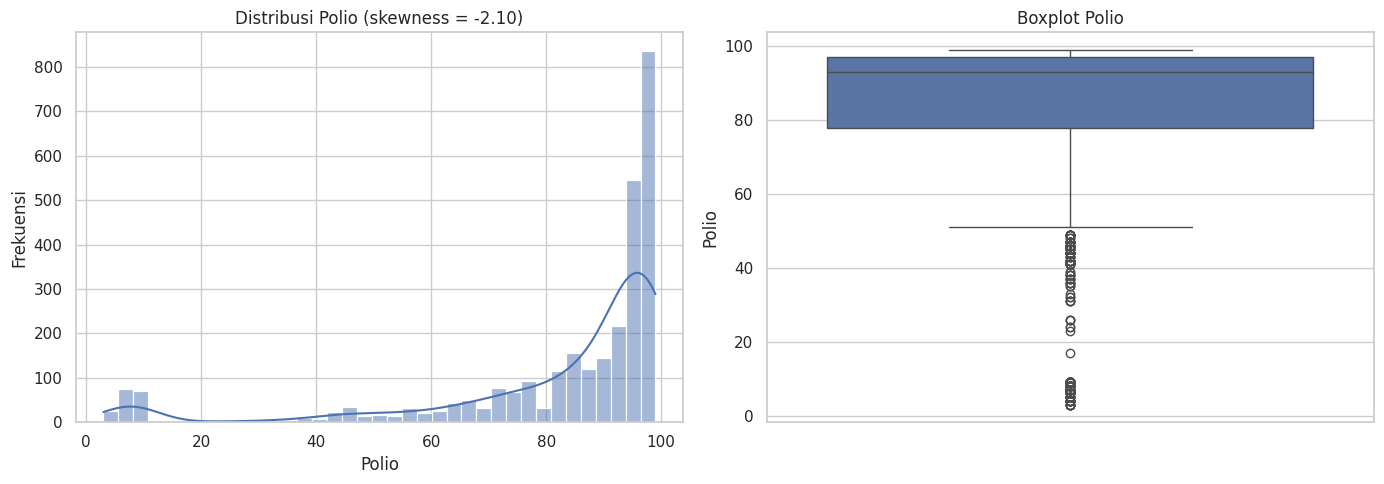

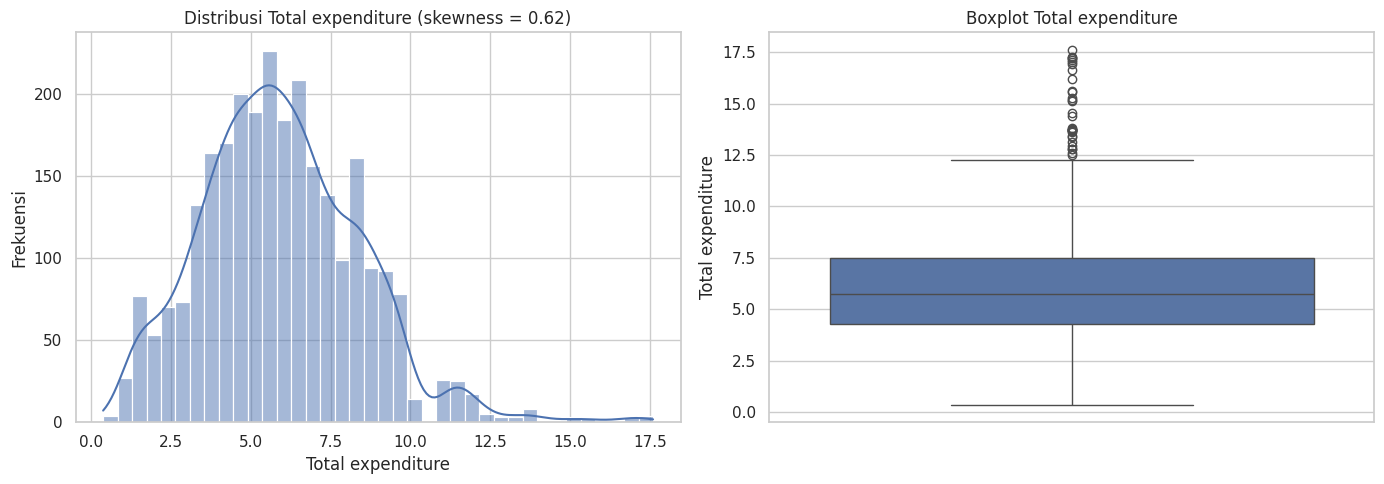

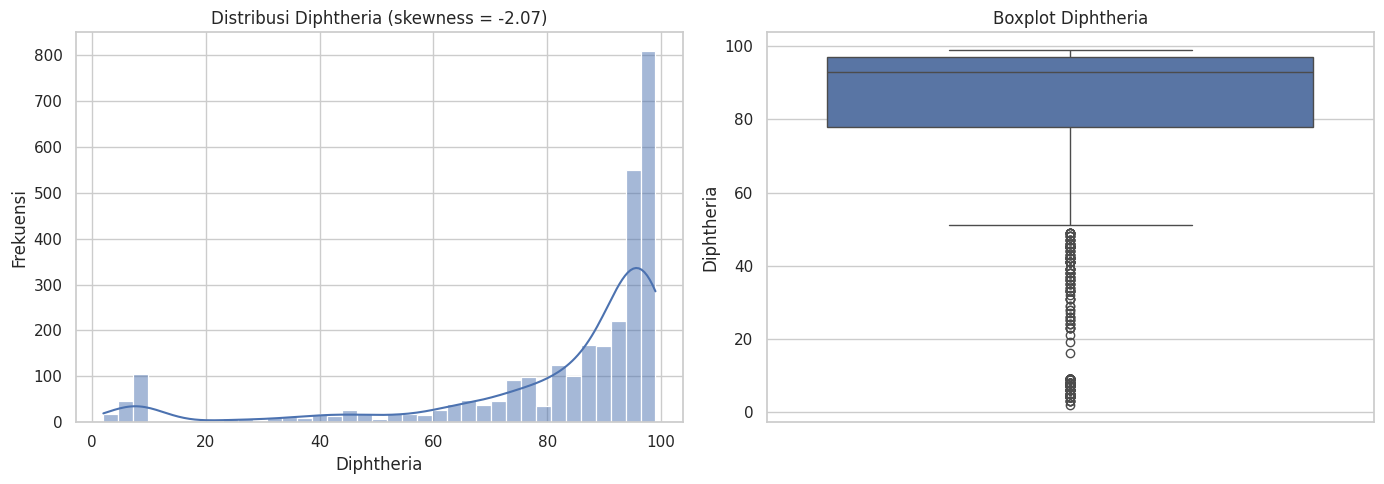

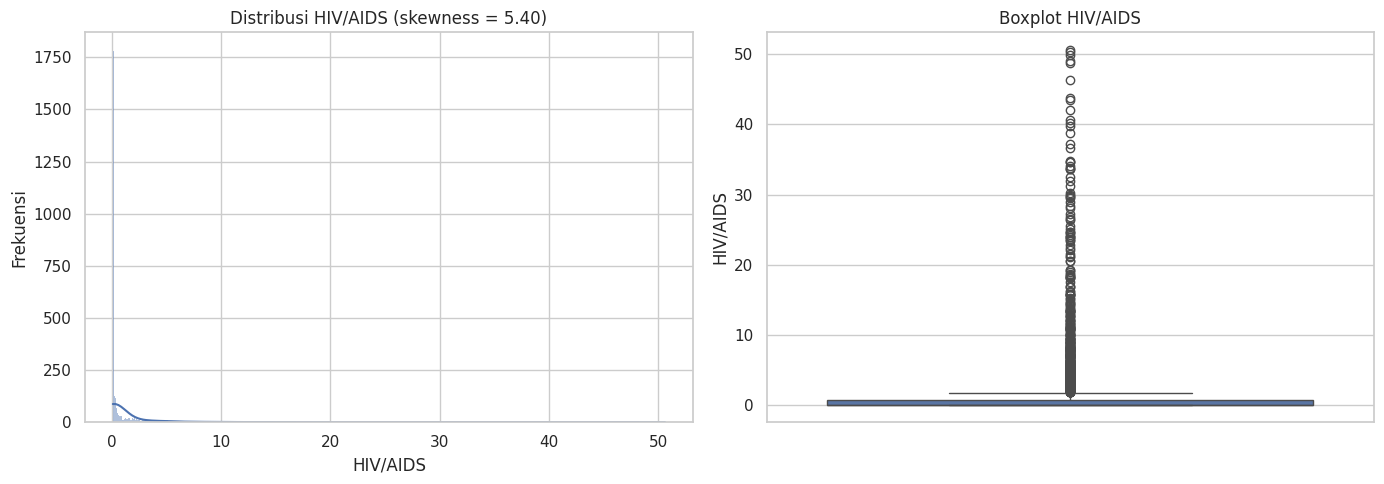

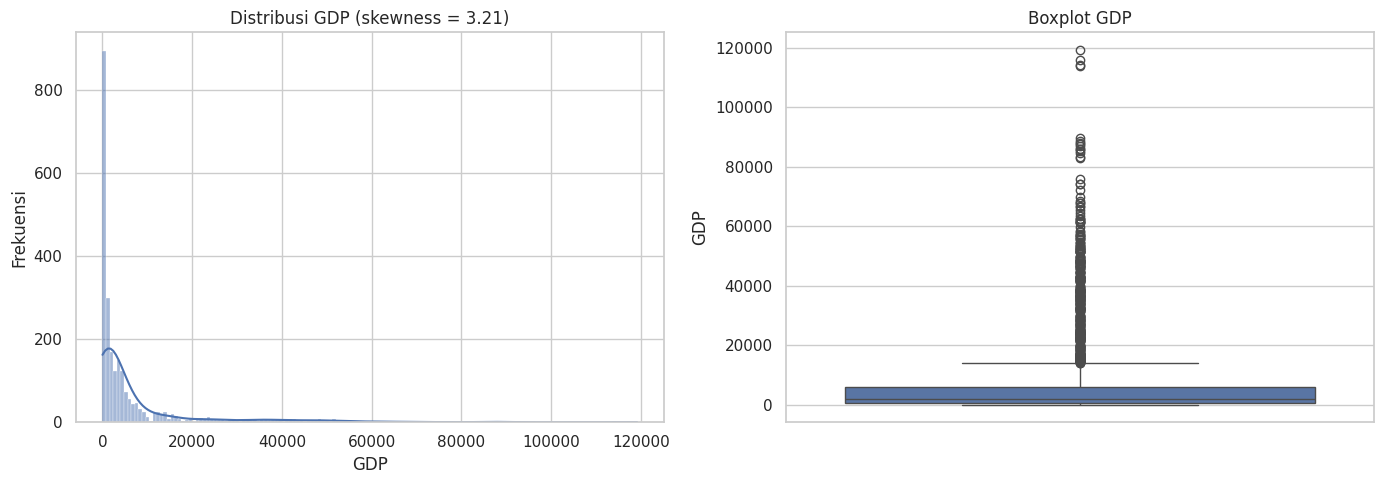

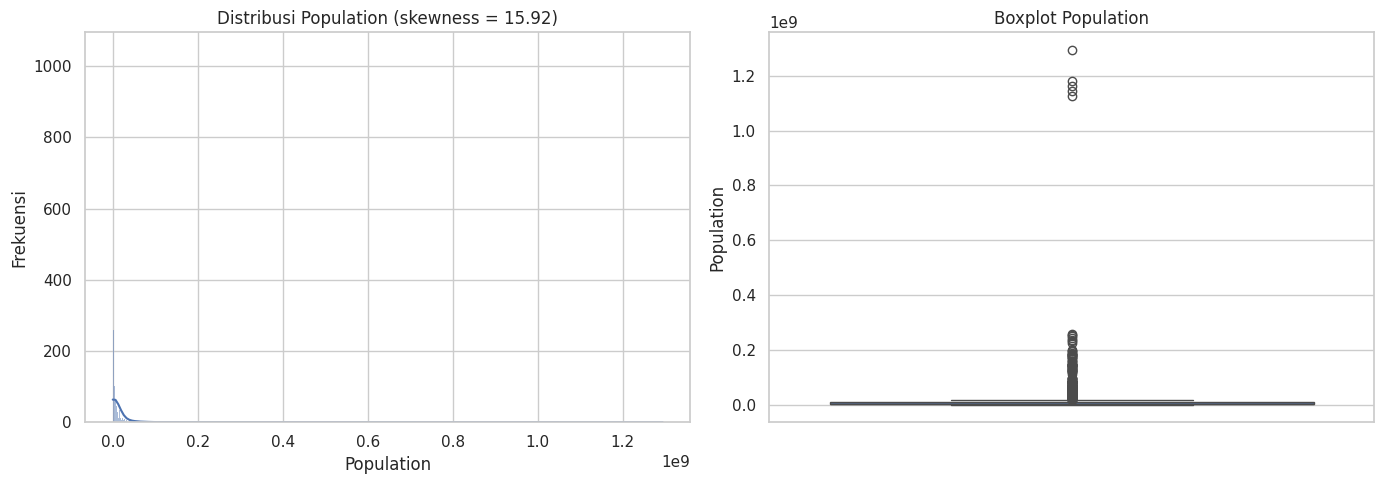

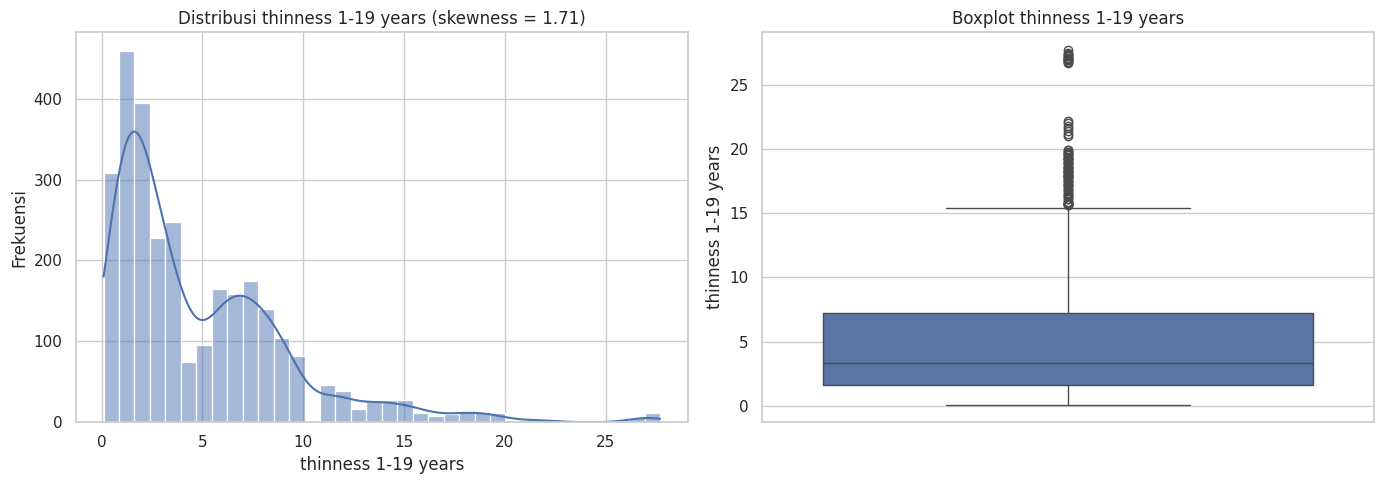

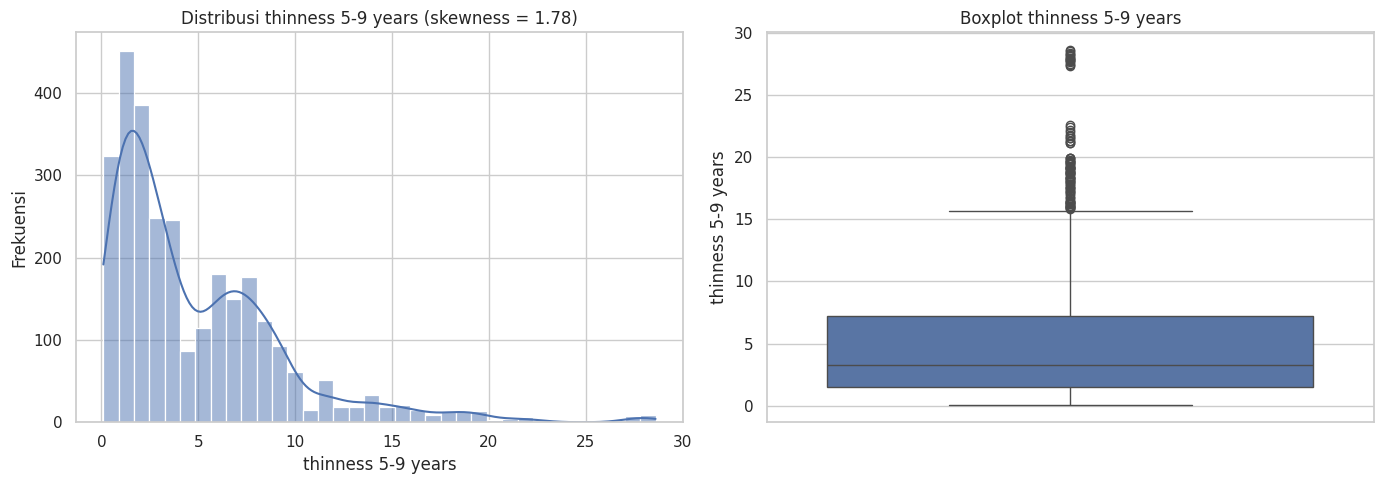

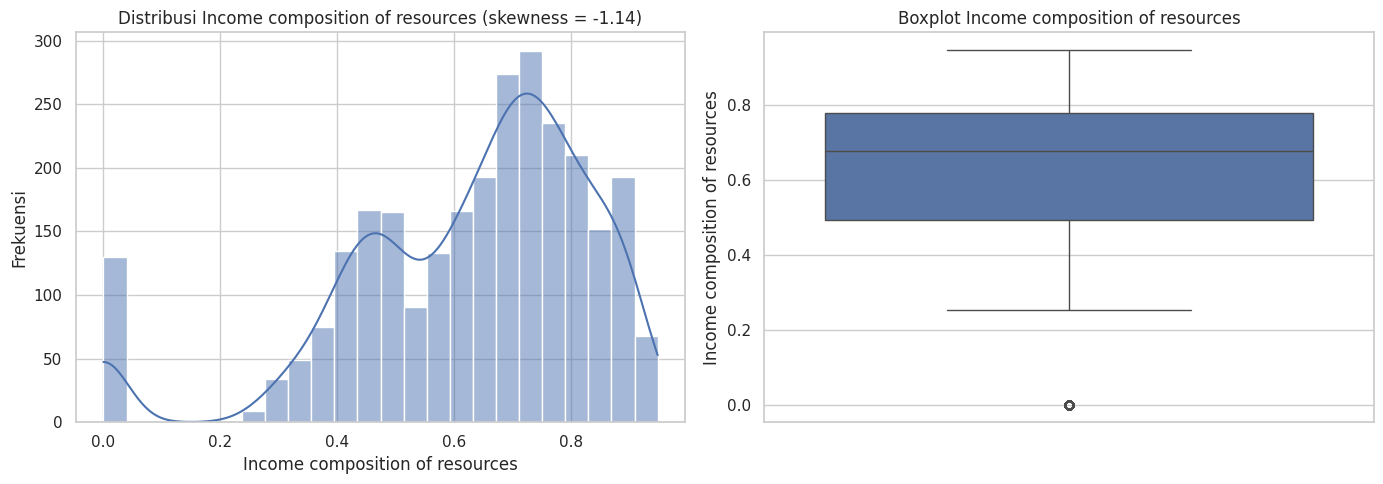

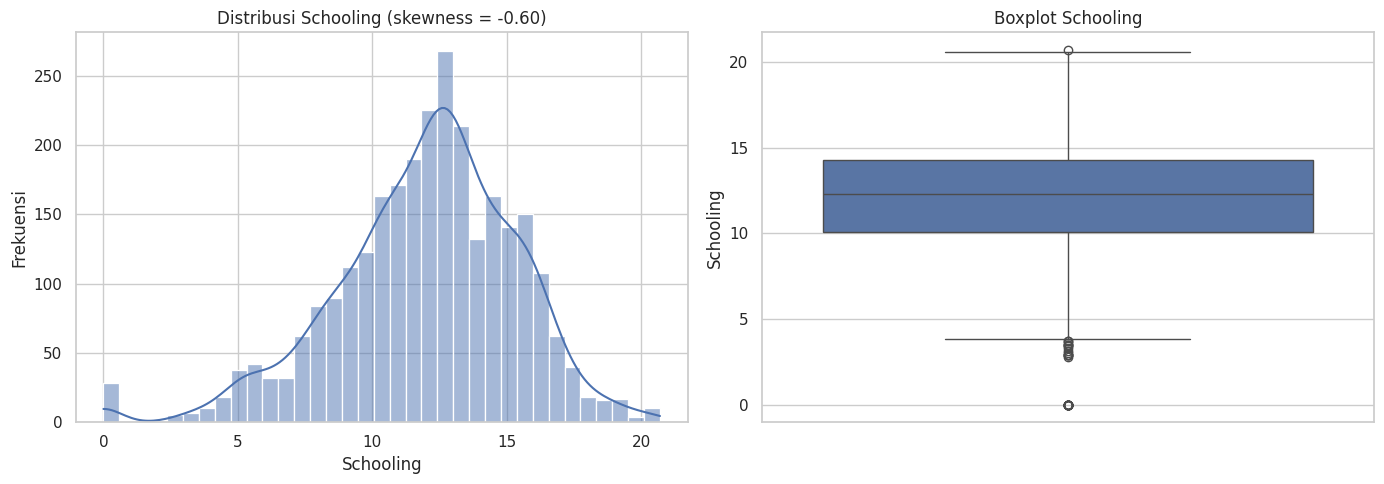


### Analisis Univariat untuk Kolom Kategorikal ###


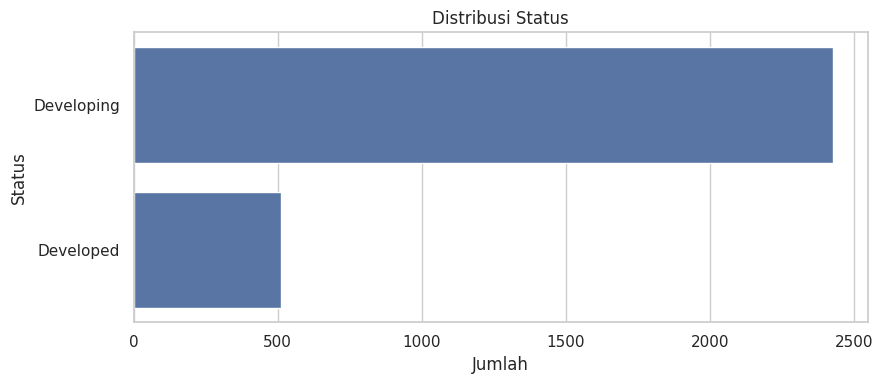

In [27]:
# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.drop('Year').tolist()
kolom_kategorikal = ['Status']   # 'Country' tidak diplot karena memiliki 193 kategori

print("### Analisis Univariat untuk Kolom Numerik ###")

for kolom in kolom_numerik:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df[kolom].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f'Distribusi {kolom} (skewness = {df[kolom].skew():.2f})')
    axes[0].set_xlabel(kolom)
    axes[0].set_ylabel('Frekuensi')

    sns.boxplot(y=df[kolom], ax=axes[1])
    axes[1].set_title(f'Boxplot {kolom}')
    axes[1].set_ylabel(kolom)

    plt.tight_layout()
    plt.show()

print("\n### Analisis Univariat untuk Kolom Kategorikal ###")

for kolom in kolom_kategorikal:
    plt.figure(figsize=(9, 4))
    sns.countplot(
        data=df,
        y=kolom,
        order=df[kolom].value_counts().index
    )
    plt.title(f'Distribusi {kolom}')
    plt.xlabel('Jumlah')
    plt.ylabel(kolom)
    plt.tight_layout()
    plt.show()

### Ringkasan Hasil Analisis Univariat

Dari analisis univariat pada dataset Life Expectancy:

- `Life expectancy` (target) menunjukkan distribusi yang **miring ke kiri**: sebagian besar negara memiliki harapan hidup 60–80 tahun, dengan sebagian kecil negara berharapan hidup sangat rendah (di bawah 50 tahun).
- `Population`, `infant deaths`, `under-five deaths`, `Measles`, `HIV/AIDS`, `percentage expenditure`, dan `GDP` **sangat miring ke kanan** (skewness besar) dengan banyak outlier. Fitur-fitur ini kandidat untuk transformasi logaritma.
- `Polio`, `Diphtheria`, dan `Hepatitis B` miring ke kiri karena mayoritas negara memiliki cakupan imunisasi tinggi (>90%).
- `Schooling`, `BMI`, dan `Income composition of resources` relatif lebih tersebar merata.
- Boxplot menunjukkan banyak outlier, tetapi sebagian besar merupakan **nilai nyata** (misalnya negara berpopulasi besar atau wabah campak), bukan kesalahan input, sehingga tidak dihapus.
- Untuk kategori, `Status` tidak seimbang: negara **Developing** jauh lebih banyak daripada **Developed**.

## **Analisis Bivariat & Multivariat (Bivariate & Multivariate Analysis)**

### 1. Heatmap Korelasi Antar Kolom Numerik ###


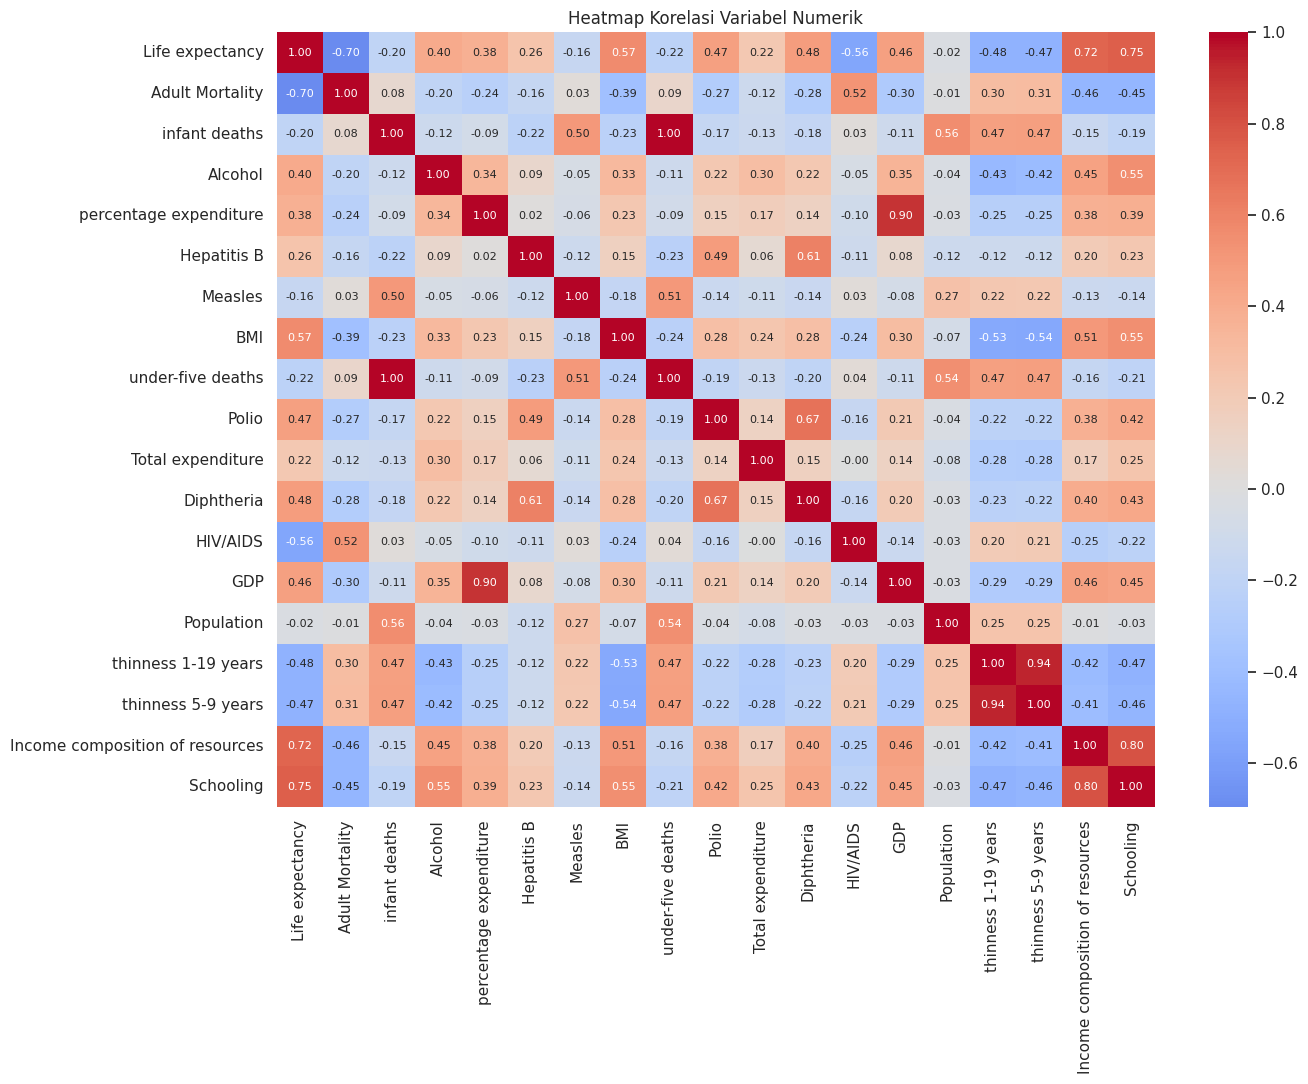


### 2. Korelasi Setiap Fitur terhadap Life expectancy ###


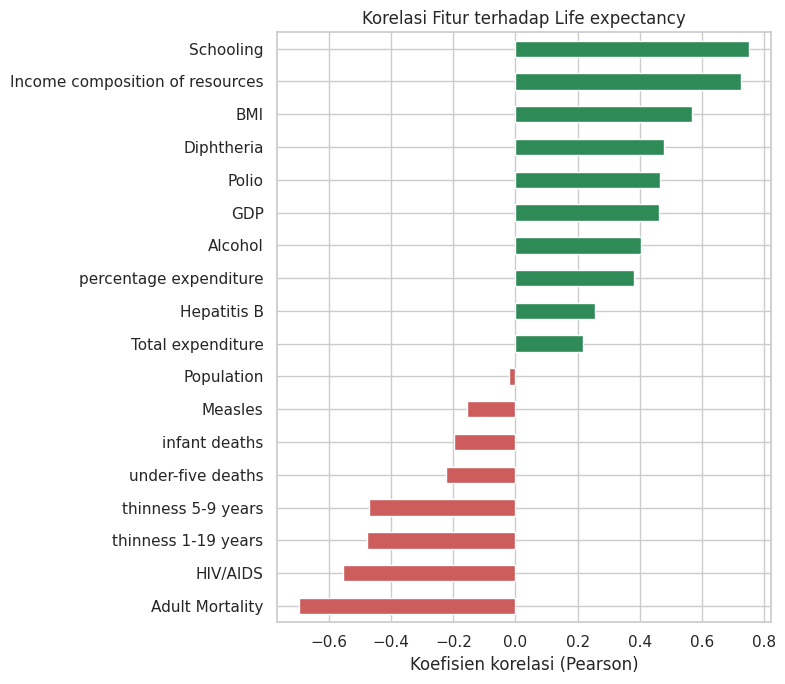


### 3. Hubungan Fitur Utama dan Life expectancy ###


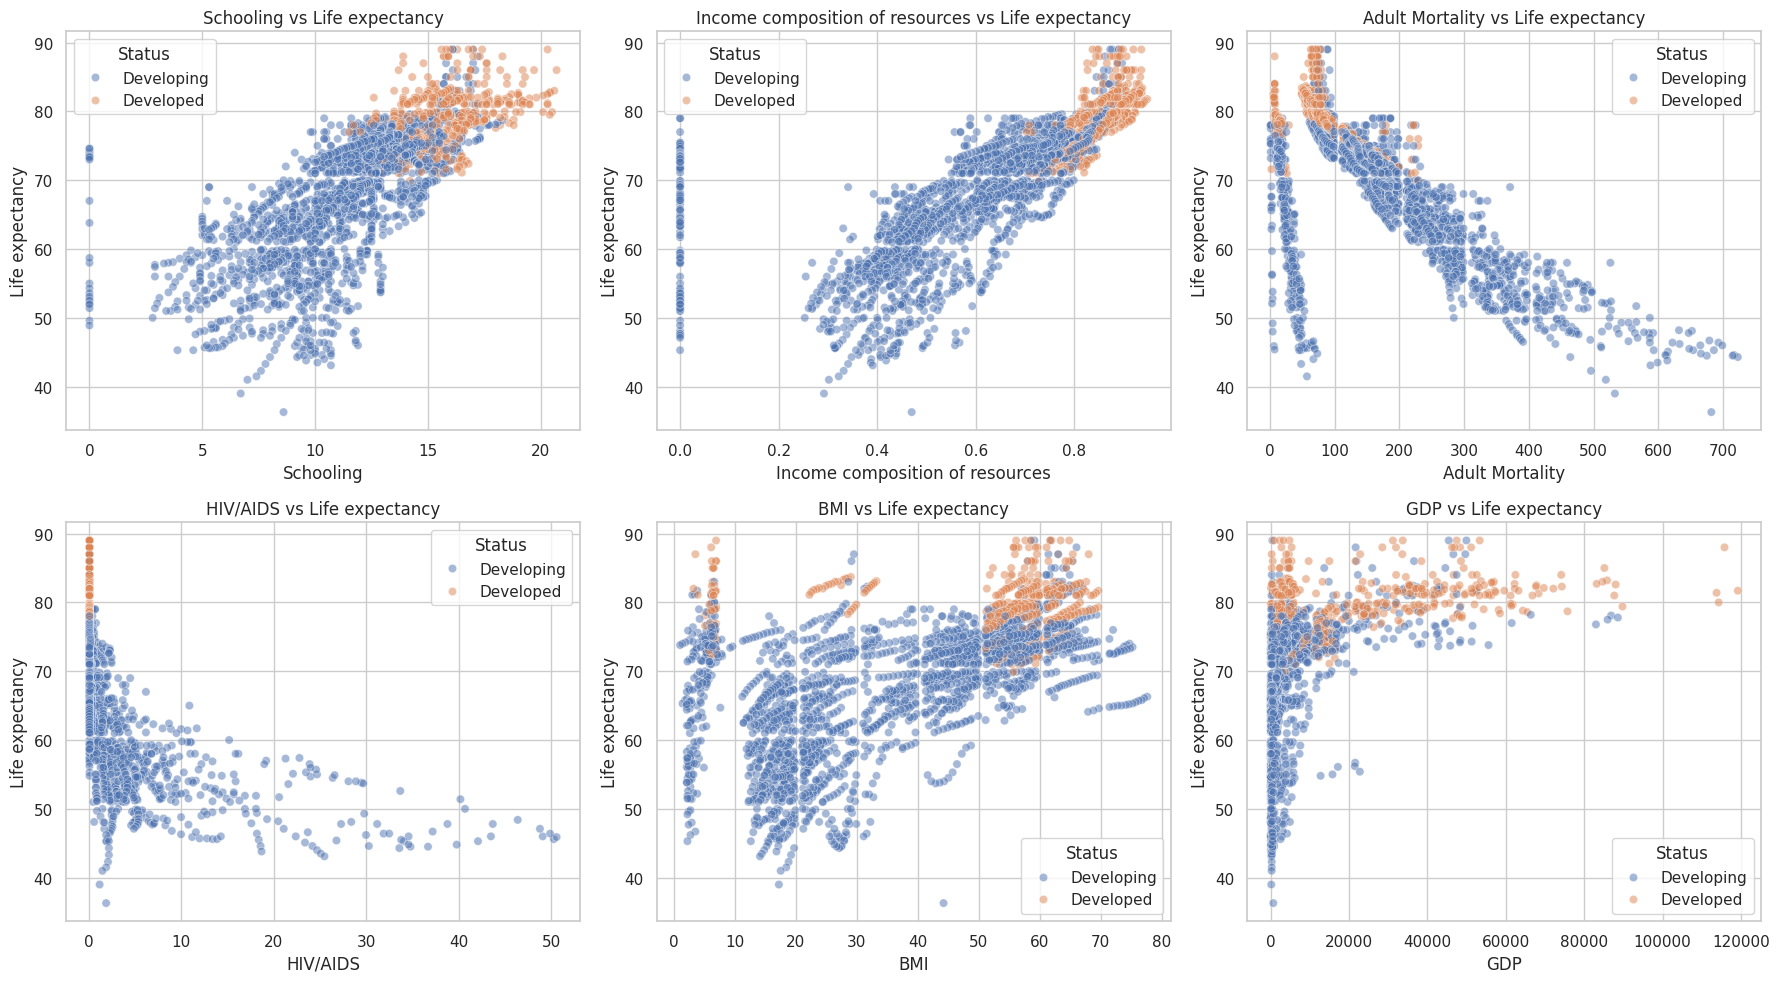


### 4. Perbandingan Life expectancy Berdasarkan Status ###


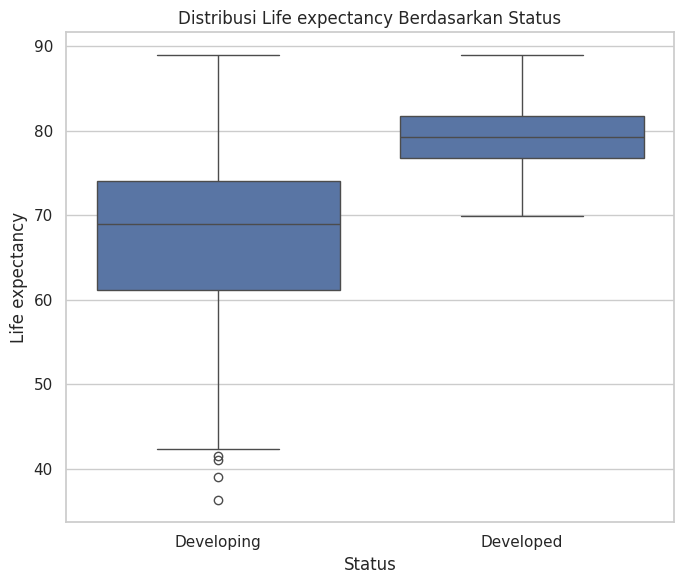

,count,mean,median,std
Status,,,,
Developed,512,79.20,79.25,3.93
Developing,2416,67.11,69.00,9.01



### 5. Tren Rata-rata Life expectancy per Tahun ###


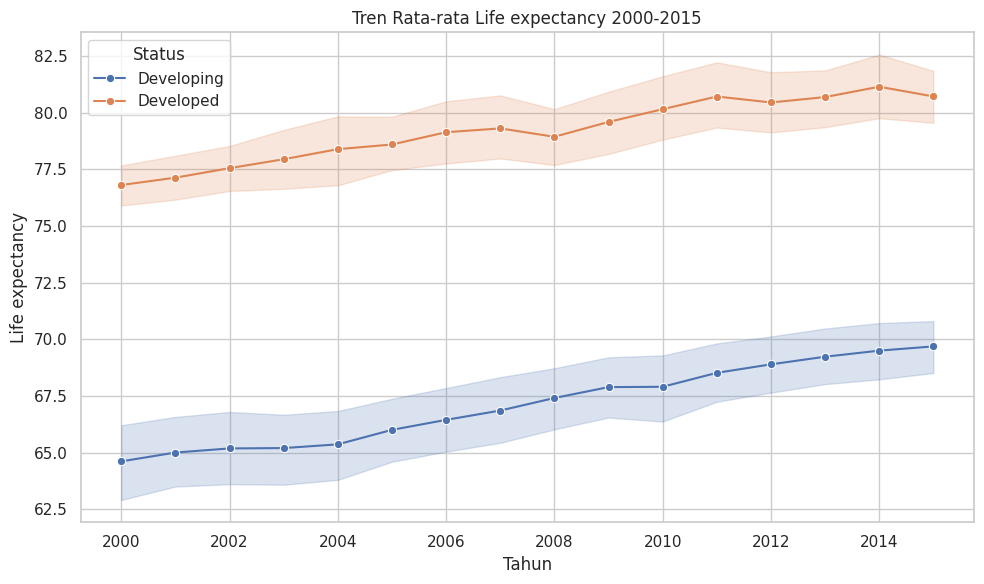

In [28]:
print("### 1. Heatmap Korelasi Antar Kolom Numerik ###")
plt.figure(figsize=(14, 11))
correlation_matrix = df.select_dtypes(include=['int64', 'float64']).drop(columns='Year').corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    annot_kws={'size': 8}
)

plt.title('Heatmap Korelasi Variabel Numerik')
plt.tight_layout()
plt.show()

print("\n### 2. Korelasi Setiap Fitur terhadap Life expectancy ###")
kor_target = correlation_matrix['Life expectancy'].drop('Life expectancy').sort_values()
plt.figure(figsize=(8, 7))
kor_target.plot(kind='barh', color=np.where(kor_target > 0, 'seagreen', 'indianred'))
plt.title('Korelasi Fitur terhadap Life expectancy')
plt.xlabel('Koefisien korelasi (Pearson)')
plt.tight_layout()
plt.show()

print("\n### 3. Hubungan Fitur Utama dan Life expectancy ###")
fitur_utama = ['Schooling', 'Income composition of resources', 'Adult Mortality', 'HIV/AIDS', 'BMI', 'GDP']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, f in zip(axes.ravel(), fitur_utama):
    sns.scatterplot(data=df, x=f, y='Life expectancy', hue='Status', alpha=0.5, ax=ax)
    ax.set_title(f'{f} vs Life expectancy')
plt.tight_layout()
plt.show()

print("\n### 4. Perbandingan Life expectancy Berdasarkan Status ###")
plt.figure(figsize=(7, 6))
sns.boxplot(data=df, x='Status', y='Life expectancy')
plt.title('Distribusi Life expectancy Berdasarkan Status')
plt.xlabel('Status')
plt.ylabel('Life expectancy')
plt.tight_layout()
plt.show()
display(df.groupby('Status')['Life expectancy'].agg(['count', 'mean', 'median', 'std']).round(2))

print("\n### 5. Tren Rata-rata Life expectancy per Tahun ###")
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Year', y='Life expectancy', hue='Status', marker='o')
plt.title('Tren Rata-rata Life expectancy 2000-2015')
plt.xlabel('Tahun')
plt.ylabel('Life expectancy')
plt.tight_layout()
plt.show()

### Ringkasan Hasil Analisis Bivariat & Multivariat

Beberapa hubungan penting yang terlihat dari dataset Life Expectancy:

1. **Schooling** (korelasi ≈ **+0,75**) dan **Income composition of resources** (≈ **+0,72**) memiliki hubungan positif paling kuat terhadap `Life expectancy`. Negara dengan pendidikan dan komposisi pendapatan lebih baik cenderung memiliki harapan hidup lebih tinggi.
2. **Adult Mortality** (≈ **−0,70**) dan **HIV/AIDS** (≈ **−0,56**) memiliki hubungan negatif yang kuat: makin tinggi angka kematian dewasa dan HIV/AIDS, makin rendah harapan hidup.
3. `BMI`, `Diphtheria`, `Polio`, `GDP`, dan `Alcohol` memiliki korelasi positif sedang (sekitar 0,4–0,57), sedangkan `thinness` berkorelasi negatif sedang (sekitar −0,47).
4. `Population` hampir tidak berkorelasi dengan `Life expectancy` (≈ −0,02).
5. Negara **Developed** memiliki rata-rata harapan hidup sekitar **79,2 tahun**, jauh di atas negara **Developing** sekitar **67,1 tahun**.
6. Rata-rata harapan hidup meningkat dari tahun ke tahun (dari sekitar 66,8 tahun pada 2000 menjadi 71,6 tahun pada 2015).
7. **Terdapat multikolinearitas antar fitur**, yang terlihat jelas pada heatmap:
   - `infant deaths` ↔ `under-five deaths` (≈ 1,00)
   - `thinness 1-19 years` ↔ `thinness 5-9 years` (≈ 0,94)
   - `GDP` ↔ `percentage expenditure` (≈ 0,90)
   - `Schooling` ↔ `Income composition of resources` (≈ 0,80)

   Hal ini perlu ditangani sebelum regresi linear karena membuat koefisien tidak stabil.

## **Catatan Kesimpulan dan Langkah Selanjutnya (Insights & Next Steps)**

### Ringkasan Temuan Utama dari Eksplorasi Data (EDA)

Berdasarkan EDA pada dataset **Life Expectancy (WHO)**, dapat disimpulkan:

1. **Dataset memiliki missing values yang masif:** 14 dari 22 kolom memiliki nilai kosong, dengan `Population`, `Hepatitis B`, dan `GDP` mengalami kehilangan data terbesar (15–22%). Tidak ada baris duplikat.
2. **Pendidikan, komposisi pendapatan, dan angka kematian dewasa sangat berkaitan dengan harapan hidup:** `Schooling` (+0,75), `Income composition of resources` (+0,72), dan `Adult Mortality` (−0,70) adalah tiga fitur dengan korelasi terkuat.
3. **Status pembangunan berpengaruh jelas:** negara Developed rata-rata memiliki harapan hidup ±12 tahun lebih tinggi daripada Developing.
4. **Banyak fitur sangat miring ke kanan dan memiliki outlier**, sehingga transformasi logaritma diperlukan.
5. **Terdapat multikolinearitas yang kuat** antara `infant deaths` dan `under-five deaths`, antara kedua kolom `thinness`, serta antara `GDP` dan `percentage expenditure`.

### Langkah Selanjutnya

EDA ini dilanjutkan dengan:
- menghapus baris yang target-nya kosong;
- menangani missing values pada fitur dengan imputasi median;
- melakukan encoding pada variabel kategorikal `Status`;
- mendeteksi multikolinearitas dengan VIF dan membuang fitur yang redundan;
- melakukan transformasi logaritma pada fitur yang sangat miring;
- membuat model regresi linear untuk memprediksi `Life expectancy`;
- mengevaluasi model dan variabel mana yang paling berpengaruh terhadap harapan hidup.

In [29]:
# Preprocessing #

# 1. Menghapus baris yang nilai targetnya (Life expectancy) kosong
print(f"Jumlah baris sebelum dibersihkan: {len(df)}")
df = df.dropna(subset=['Life expectancy']).copy()
print(f"Jumlah baris setelah target kosong dihapus: {len(df)}")

# Pengecekan duplikat (tidak ada duplikat pada dataset ini)
df.drop_duplicates(keep='first', inplace=True)
print(f"Jumlah baris setelah cek duplikat: {len(df)}")

display(df.head())

Jumlah baris sebelum dibersihkan: 2938
Jumlah baris setelah target kosong dihapus: 2928
Jumlah baris setelah cek duplikat: 2928


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [30]:
# 2. Mengecek missing value setelah target dibersihkan

print("Jumlah missing value setiap kolom:")
print(df.isnull().sum())

print("\nTotal missing value:")
print(df.isnull().sum().sum())

Jumlah missing value setiap kolom:
Country                              0
Year                                 0
Status                               0
Life expectancy                      0
Adult Mortality                      0
infant deaths                        0
Alcohol                            193
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 32
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                443
Population                         644
thinness 1-19 years                 32
thinness 5-9 years                  32
Income composition of resources    160
Schooling                          160
dtype: int64

Total missing value:
2513


In [31]:
# 3. Ordinal/Binary Encoding pada variabel Status
# Developing = 0, Developed = 1

df['Status'] = df['Status'].map({
    'Developing': 0,
    'Developed': 1
}).astype(int)

display(df[['Status']].head(10))

,Status
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [32]:
# 4. Menghapus kolom yang tidak digunakan sebagai fitur
# 'Country' : 193 kategori nama negara (identitas, bukan fitur numerik)
# 'Year'    : hanya penanda waktu

df = df.drop(columns=['Country', 'Year'])
print("Kolom yang tersisa:")
print(df.columns.tolist())

Kolom yang tersisa:
['Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness 1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [33]:
# 5. Memisahkan fitur (X) dan target (y)

X = df.drop(columns=['Life expectancy'])
y = df['Life expectancy']

print("Fitur (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Fitur (X):


,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,0,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,0,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,0,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,0,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5



Target (y):


,Life expectancy
0,65.0
1,59.9
2,59.9
3,59.5
4,59.2


### Deteksi Multikolinearitas dengan VIF

Multikolinearitas terjadi ketika dua atau lebih fitur saling berkorelasi tinggi sehingga koefisien regresi menjadi tidak stabil dan sulit diinterpretasikan.
**VIF (Variance Inflation Factor)** dihitung dengan rumus `VIF = 1 / (1 − R²)`, di mana R² diperoleh dari meregresikan satu fitur terhadap semua fitur lainnya.

Aturan praktis: VIF < 5 aman, 5–10 perlu diwaspadai, **VIF > 10 bermasalah**.

,VIF
infant deaths,177.20
under-five deaths,176.16
thinness 5-9 years,8.85
thinness 1-19 years,8.75
GDP,5.99
percentage expenditure,5.77
Schooling,3.40
Income composition of resources,3.05
Diphtheria,2.15
Polio,1.93


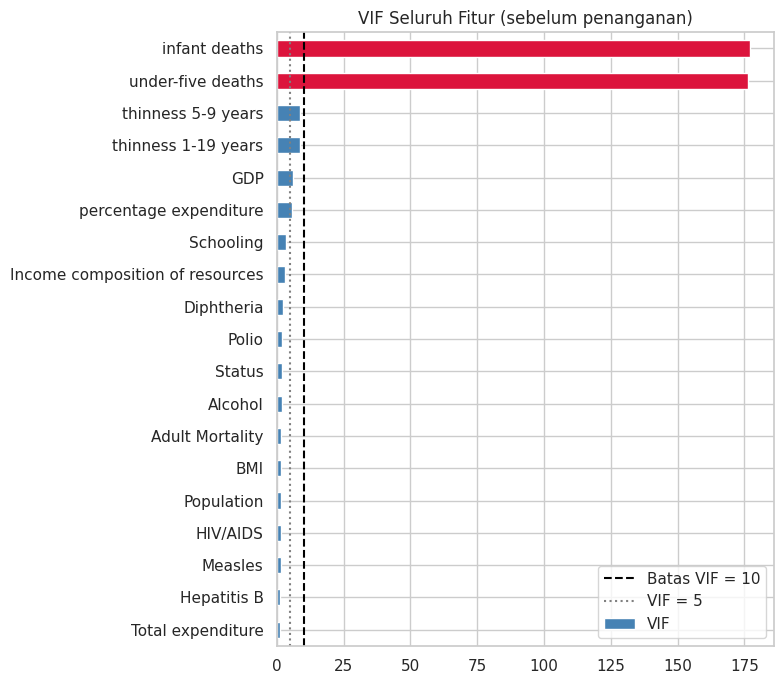

In [34]:
# 6. Menghitung VIF untuk mendeteksi multikolinearitas
# (imputasi median sementara hanya untuk menghitung VIF; imputasi final dilakukan setelah split)

from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

def hitung_vif(data):
    # VIF dihitung manual: 1 / (1 - R2) dari regresi tiap fitur terhadap fitur lainnya
    hasil = {}
    for kolom in data.columns:
        lain = data.drop(columns=kolom)
        r2 = LinearRegression().fit(lain, data[kolom]).score(lain, data[kolom])
        hasil[kolom] = 1 / (1 - r2) if r2 < 1 else np.inf
    return pd.Series(hasil, name='VIF').sort_values(ascending=False)

X_sementara = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(X),
    columns=X.columns
)

vif_awal = hitung_vif(X_sementara)
display(vif_awal.round(2).to_frame())

plt.figure(figsize=(8, 7))
vif_urut = vif_awal.sort_values()
vif_urut.plot(kind='barh', color=np.where(vif_urut > 10, 'crimson', 'steelblue'))
plt.axvline(10, color='black', linestyle='--', label='Batas VIF = 10')
plt.axvline(5, color='gray', linestyle=':', label='VIF = 5')
plt.title('VIF Seluruh Fitur (sebelum penanganan)')
plt.legend()
plt.tight_layout()
plt.show()

### Hasil VIF dan Keputusan

- `infant deaths` dan `under-five deaths` memiliki **VIF ≈ 177** (hampir identik, korelasi ≈ 1,00).
- `thinness 1-19 years` dan `thinness 5-9 years` memiliki **VIF ≈ 8,8** (borderline tinggi).
- `GDP` dan `percentage expenditure` memiliki **VIF ≈ 6** (perlu diwaspadai).

Dari setiap pasangan fitur redundan, **satu fitur dibuang**:

| Dibuang | Dipertahankan | Alasan |
|---|---|---|
| `under-five deaths` | `infant deaths` | korelasi ≈ 1,00 (informasi duplikat) |
| `thinness 5-9 years` | `thinness 1-19 years` | korelasi 0,94, rentang usia mencakup |
| `percentage expenditure` | `GDP` | berkorelasi 0,90; GDP lebih bermakna secara ekonomi |

In [35]:
# 7. Menghapus fitur multikolinear

fitur_dibuang = ['under-five deaths', 'thinness 5-9 years', 'percentage expenditure']
X = X.drop(columns=fitur_dibuang)

print("Fitur yang dibuang:", fitur_dibuang)
print("Fitur yang tersisa:", X.columns.tolist())
print("Jumlah fitur:", X.shape[1])

Fitur yang dibuang: ['under-five deaths', 'thinness 5-9 years', 'percentage expenditure']
Fitur yang tersisa: ['Status', 'Adult Mortality', 'infant deaths', 'Alcohol', 'Hepatitis B', 'Measles', 'BMI', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness 1-19 years', 'Income composition of resources', 'Schooling']
Jumlah fitur: 16


In [36]:
# 8. Transformasi logaritma (log1p) pada fitur yang sangat miring ke kanan

kolom_log = ['GDP', 'Population', 'Measles', 'infant deaths', 'HIV/AIDS']

for kolom in kolom_log:
    X[kolom] = np.log1p(X[kolom])

print("Skewness setelah transformasi log:")
display(X[kolom_log].skew().round(2).to_frame('skewness'))

Skewness setelah transformasi log:


,skewness
GDP,-0.14
Population,-0.55
Measles,0.55
infant deaths,0.70
HIV/AIDS,2.12


In [37]:
# 9. Membagi data menjadi training dan testing (80% : 20%)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

Ukuran X_train: (2342, 16)
Ukuran X_test : (586, 16)
Ukuran y_train: (2342,)
Ukuran y_test : (586,)


In [38]:
# 10. Imputasi missing value dengan median
# Median dipelajari HANYA dari data training, lalu diterapkan ke data testing (mencegah data leakage)

imputer = SimpleImputer(strategy='median')

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

X_train = pd.DataFrame(X_train_imp, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_imp, columns=X_test.columns, index=X_test.index)

display(X_train.head())

,Status,Adult Mortality,infant deaths,Alcohol,Hepatitis B,Measles,BMI,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,Income composition of resources,Schooling
2268,0.0,126.0,0.693147,9.38,97.0,0.000000,58.3,93.0,9.89,91.0,0.095310,8.641247,13.486976,2.1,0.7670,14.0
1680,0.0,179.0,0.000000,4.14,88.0,0.000000,26.4,88.0,4.24,88.0,0.095310,8.283624,11.733040,7.9,0.6830,12.5
2785,0.0,376.0,4.532599,3.44,86.0,8.135640,19.6,89.0,4.21,86.0,2.128232,7.458104,14.184283,7.3,0.6755,12.3
2512,1.0,62.0,0.000000,6.90,92.0,3.258097,56.5,98.0,9.23,98.0,0.095310,10.928594,16.036846,1.3,0.8970,15.7
1090,0.0,275.0,1.609438,3.72,87.0,5.036953,26.3,87.0,5.70,87.0,1.435085,6.393376,12.086878,7.1,0.4210,9.2


In [39]:
# 11. Verifikasi hasil preprocessing

print("Missing value X_train:", X_train.isnull().sum().sum())
print("Missing value X_test :", X_test.isnull().sum().sum())

print("\nTipe data X_train:")
print(X_train.dtypes)

Missing value X_train: 0
Missing value X_test : 0

Tipe data X_train:
Status                             float64
Adult Mortality                    float64
infant deaths                      float64
Alcohol                            float64
Hepatitis B                        float64
Measles                            float64
BMI                                float64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
thinness 1-19 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object


,VIF
Schooling,3.56
Income composition of resources,3.04
infant deaths,2.99
Diphtheria,2.10
Polio,1.91
HIV/AIDS,1.88
Status,1.85
Measles,1.83
Alcohol,1.83
Adult Mortality,1.82


VIF maksimum sebelum: 177.20
VIF maksimum sesudah : 3.56


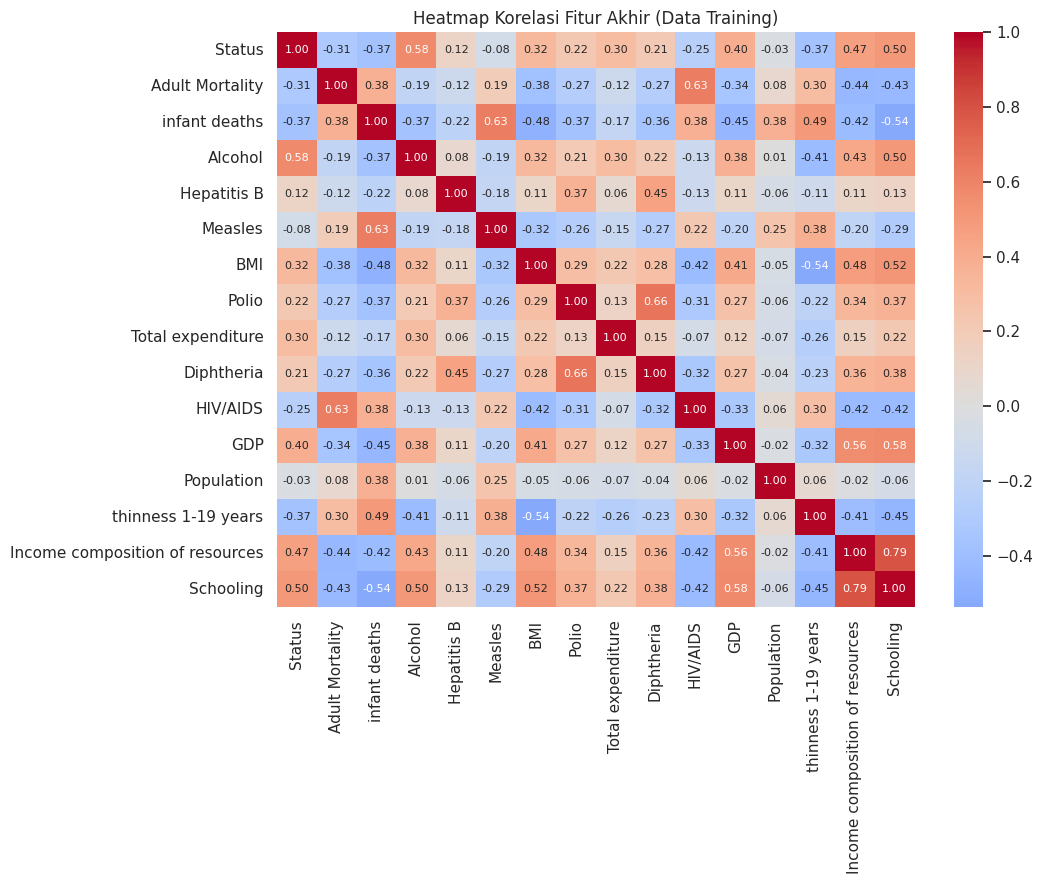

In [40]:
# 12. Verifikasi VIF setelah penanganan multikolinearitas

vif_akhir = hitung_vif(X_train)
display(vif_akhir.round(2).to_frame())

print(f"VIF maksimum sebelum: {vif_awal.max():.2f}")
print(f"VIF maksimum sesudah : {vif_akhir.max():.2f}")

plt.figure(figsize=(11, 9))
sns.heatmap(X_train.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0, annot_kws={'size': 8})
plt.title('Heatmap Korelasi Fitur Akhir (Data Training)')
plt.tight_layout()
plt.show()

**Hasil:** setelah fitur redundan dibuang, VIF maksimum turun dari ±177 menjadi di bawah 4. Seluruh fitur kini berada pada kategori aman (VIF < 5), sehingga multikolinearitas sudah terkendali dan koefisien regresi lebih dapat diandalkan.

In [41]:
# 13. Standardisasi fitur (hanya untuk membandingkan pengaruh relatif antar fitur)
# Model utama tetap dilatih pada data skala asli agar koefisien mudah diinterpretasikan

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_std = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
display(X_train_std.describe().round(2))

,Status,Adult Mortality,infant deaths,Alcohol,Hepatitis B,Measles,BMI,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,Income composition of resources,Schooling
count,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00,2342.00
mean,0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.46,-1.33,-1.07,-1.16,-3.55,-1.03,-1.86,-3.40,-2.29,-3.33,-0.55,-3.76,-4.43,-1.08,-3.11,-3.69
25%,-0.46,-0.74,-1.07,-0.88,-0.04,-1.03,-0.94,-0.23,-0.63,-0.17,-0.55,-0.65,-0.42,-0.74,-0.64,-0.56
50%,-0.46,-0.17,-0.23,-0.21,0.40,-0.14,0.24,0.45,-0.08,0.42,-0.55,0.00,0.09,-0.35,0.23,0.09
75%,-0.46,0.50,0.81,0.72,0.57,0.78,0.90,0.62,0.59,0.62,0.09,0.58,0.60,0.52,0.70,0.64
max,2.19,4.43,3.43,3.42,0.70,2.73,1.98,0.71,4.85,0.71,4.42,2.44,2.98,5.17,1.57,2.67


In [42]:
# 14. Menyiapkan data untuk regresi linear
# Menggunakan data hasil imputasi (skala asli, sebelum standardisasi)

X_train_reg = X_train.copy()
X_test_reg = X_test.copy()
y_train_reg = y_train.copy()
y_test_reg = y_test.copy()

print("Data training:", X_train_reg.shape)
print("Data testing :", X_test_reg.shape)

Data training: (2342, 16)
Data testing : (586, 16)


In [43]:
# 15. Membuat dan melatih model regresi linear

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_reg, y_train_reg)

print("Model regresi linear berhasil dilatih.")

Model regresi linear berhasil dilatih.


In [44]:
# 16. Melihat intercept dan koefisien model

print("Intercept:", model.intercept_)

print("\nKoefisien setiap fitur:")

for nama, koef in zip(X_train_reg.columns, model.coef_):
    print(nama, "=", round(koef, 3))

Intercept: 58.699257723462075

Koefisien setiap fitur:
Status = 1.505
Adult Mortality = -0.015
infant deaths = -0.747
Alcohol = 0.048
Hepatitis B = -0.02
Measles = -0.015
BMI = 0.011
Polio = 0.021
Total expenditure = 0.093
Diphtheria = 0.034
HIV/AIDS = -4.806
GDP = 0.396
Population = 0.081
thinness 1-19 years = -0.059
Income composition of resources = 6.226
Schooling = 0.399


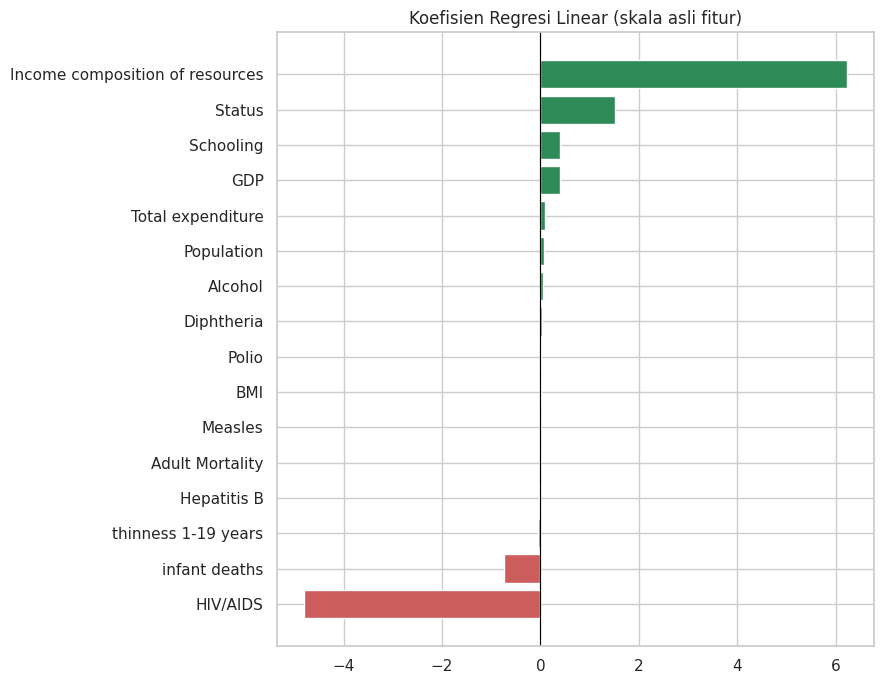

In [45]:
# 17. Visualisasi koefisien model

tabel_koef = pd.DataFrame({'Fitur': X_train_reg.columns, 'Koefisien': model.coef_}).sort_values('Koefisien')

plt.figure(figsize=(9, 7))
plt.barh(tabel_koef['Fitur'], tabel_koef['Koefisien'],
         color=np.where(tabel_koef['Koefisien'] > 0, 'seagreen', 'indianred'))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Koefisien Regresi Linear (skala asli fitur)')
plt.tight_layout()
plt.show()

In [46]:
# 18. Koefisien terstandarisasi untuk membandingkan pengaruh relatif antar fitur
# (koefisien skala asli tidak bisa dibandingkan langsung karena satuan tiap fitur berbeda)

model_std = LinearRegression()
model_std.fit(X_train_scaled, y_train_reg)

koef_std = pd.Series(model_std.coef_, index=X_train_reg.columns)
display(koef_std.sort_values(key=abs, ascending=False).round(3).to_frame('Koefisien standar'))

,Koefisien standar
HIV/AIDS,-3.720
Adult Mortality,-1.817
Schooling,1.297
Income composition of resources,1.262
infant deaths,-1.246
Diphtheria,0.810
GDP,0.681
Status,0.569
Polio,0.489
Hepatitis B,-0.471


### Interpretasi Koefisien

Koefisien menyatakan perubahan rata-rata `Life expectancy` (tahun) apabila fitur naik 1 satuan dengan fitur lain dianggap tetap (*ceteris paribus*). Untuk fitur yang ditransformasi log (`GDP`, `Population`, `Measles`, `infant deaths`, `HIV/AIDS`), 1 satuan berarti kenaikan 1 satuan pada skala log (kira-kira kenaikan proporsional pada nilai aslinya).

- **`Income composition of resources` (≈ +6,23):** indeks 0–1; kenaikan 0,1 poin dikaitkan dengan tambahan harapan hidup ≈ 0,6 tahun.
- **`HIV/AIDS` (≈ −4,81):** pengaruh negatif terbesar pada skala asli; makin tinggi angka HIV/AIDS, makin rendah harapan hidup. Pada koefisien terstandarisasi, fitur ini juga paling berpengaruh.
- **`Status` (≈ +1,51):** negara Developed rata-rata memiliki harapan hidup ±1,5 tahun lebih tinggi daripada Developing, dengan fitur lain sama.
- **`infant deaths` (≈ −0,75):** makin banyak kematian bayi, makin rendah harapan hidup.
- **`Schooling` (≈ +0,40):** tiap tambahan 1 tahun pendidikan dikaitkan dengan ≈ +0,4 tahun harapan hidup.
- **`Adult Mortality` (≈ −0,015):** koefisien tampak kecil karena satuannya besar (per 1.000 penduduk, rentang hingga ±700), tetapi pada koefisien terstandarisasi pengaruhnya termasuk besar.

> Regresi hanya menunjukkan **asosiasi**, bukan hubungan sebab-akibat.

In [47]:
# 19. Membuat prediksi pada data testing

y_pred = model.predict(X_test_reg)

print("5 hasil prediksi pertama:")
print(y_pred[:5])

5 hasil prediksi pertama:
[52.20263364 68.31954143 80.17487318 78.83682974 53.7167237 ]


In [48]:
# 20. Evaluasi model menggunakan MSE, RMSE, dan R²

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred)

print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 3))

MSE  : 12.91
RMSE : 3.59
R²   : 0.851


In [49]:
# 21. Perbandingan performa data training dan testing (cek overfitting)

y_pred_train = model.predict(X_train_reg)

mse_train = mean_squared_error(y_train_reg, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train_reg, y_pred_train)

perbandingan = pd.DataFrame({
    'MSE': [mse_train, mse],
    'RMSE': [rmse_train, rmse],
    'R²': [r2_train, r2]
}, index=['Training', 'Testing'])

display(perbandingan.round(3))

,MSE,RMSE,R²
Training,13.246,3.640,0.856
Testing,12.913,3.593,0.851


### Interpretasi Metrik

- **RMSE ≈ 3,59 tahun:** rata-rata prediksi meleset sekitar 3,6 tahun dari harapan hidup sebenarnya (satuannya sama dengan target).
- **R² ≈ 0,85:** model menjelaskan sekitar 85% variasi harapan hidup pada data testing.
- Nilai metrik pada data training dan testing **sangat berdekatan** (R² ≈ 0,856 vs 0,851), sehingga tidak ada indikasi overfitting.

In [50]:
# 22. Menghitung residual

residual = y_test_reg - y_pred

print("5 residual pertama:")
print(residual.head())

print(f"\nRata-rata residual: {residual.mean():.3f}")
print(f"Simpangan baku residual: {residual.std():.3f}")

5 residual pertama:
2399    4.297366
196     4.680459
2316    2.325127
1735   -3.236830
1102   -0.716724
Name: Life expectancy, dtype: float64

Rata-rata residual: -0.063
Simpangan baku residual: 3.596


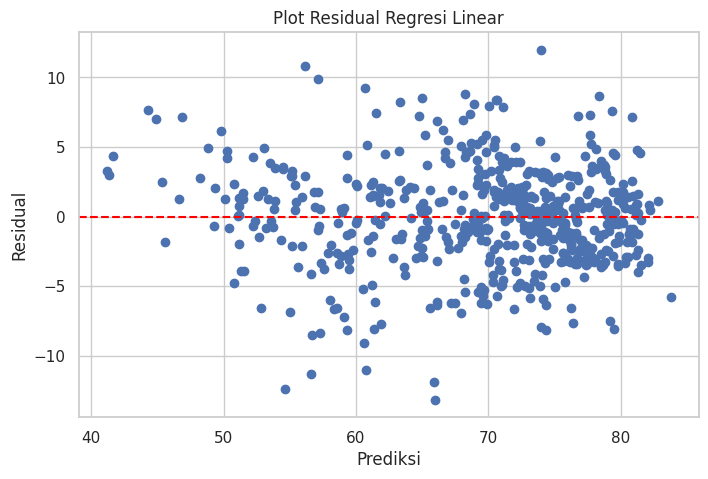

In [51]:
# 23. Visualisasi residual

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residual)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel('Prediksi')
plt.ylabel('Residual')
plt.title('Plot Residual Regresi Linear')

plt.show()

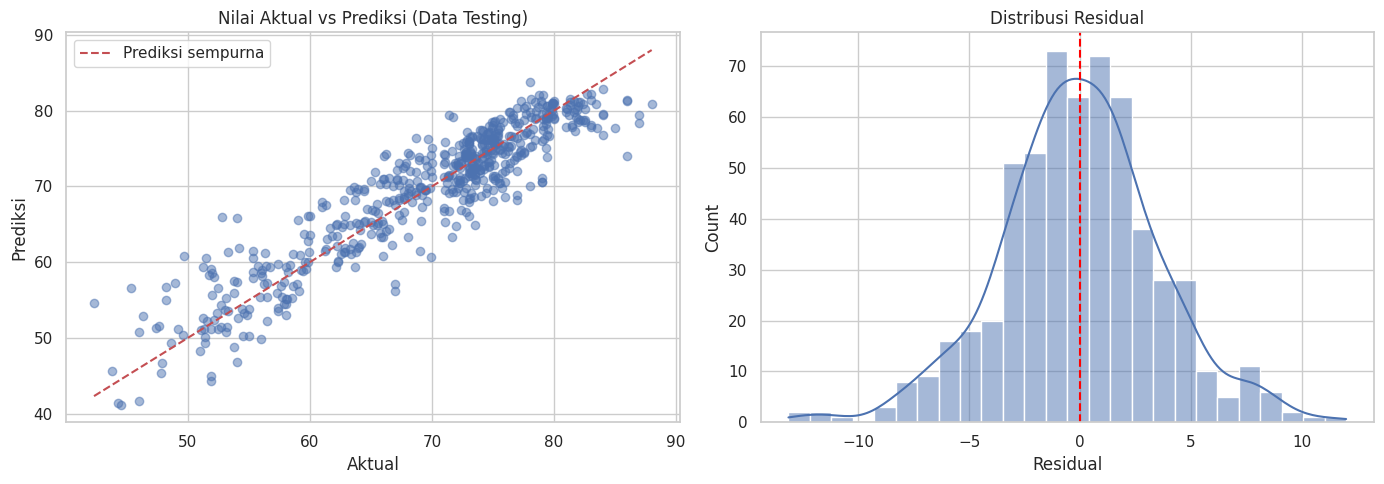

In [52]:
# 24. Visualisasi tambahan: nilai aktual vs prediksi dan distribusi residual

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_reg, y_pred, alpha=0.5)
batas = [y_test_reg.min(), y_test_reg.max()]
axes[0].plot(batas, batas, 'r--', label='Prediksi sempurna')
axes[0].set_xlabel('Aktual')
axes[0].set_ylabel('Prediksi')
axes[0].set_title('Nilai Aktual vs Prediksi (Data Testing)')
axes[0].legend()

sns.histplot(residual, kde=True, ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_title('Distribusi Residual')

plt.tight_layout()
plt.show()

### Analisis Residual

- **Aktual vs prediksi:** titik-titik mengikuti garis diagonal sehingga model menangkap pola utama harapan hidup.
- **Plot residual:** sebaran residual acak di sekitar nol tanpa pola melengkung yang kuat, sehingga asumsi linearitas dan varians galat konstan cukup terpenuhi. Beberapa residual besar muncul pada prediksi harapan hidup rendah (negara dengan HIV/AIDS tinggi atau konflik) yang lebih sulit diprediksi.
- **Distribusi residual:** mendekati simetris dan berpusat di sekitar nol (rata-rata ≈ −0,06), mendukung asumsi galat berdistribusi normal.

In [53]:
# 25. Perbandingan dampak preprocessing (3 skenario pada data testing yang sama)

def jalankan_skenario(buang, log):
    d = pd.read_csv(NAMA_FILE)
    d.columns = d.columns.str.strip().str.replace(r'\s+', ' ', regex=True)
    d = d.dropna(subset=['Life expectancy'])
    d['Status'] = d['Status'].map({'Developing': 0, 'Developed': 1})
    d = d.drop(columns=['Country', 'Year'] + buang)
    for k in log:
        d[k] = np.log1p(d[k])
    Xs, ys = d.drop(columns='Life expectancy'), d['Life expectancy']
    a, b, c, e = train_test_split(Xs, ys, test_size=0.2, random_state=42)
    imp = SimpleImputer(strategy='median').fit(a)
    m = LinearRegression().fit(imp.transform(a), c)
    p = m.predict(imp.transform(b))
    return Xs.shape[1], np.sqrt(mean_squared_error(e, p)), r2_score(e, p)

skenario = {
    'A. Semua fitur, tanpa log': ([], []),
    'B. Buang fitur multikolinear, tanpa log': (fitur_dibuang, []),
    'C. B + transformasi log (model akhir)': (fitur_dibuang, kolom_log),
}

baris = []
for nama, (buang, lg) in skenario.items():
    jml, rm, r2_s = jalankan_skenario(buang, lg)
    baris.append({'Skenario': nama, 'Jumlah fitur': jml, 'RMSE': round(rm, 3), 'R²': round(r2_s, 3)})

display(pd.DataFrame(baris))

,Skenario,Jumlah fitur,RMSE,R²
0,"A. Semua fitur, tanpa log",19,3.952,0.819
1,"B. Buang fitur multikolinear, tanpa log",16,4.068,0.809
2,C. B + transformasi log (model akhir),16,3.593,0.851


In [54]:
# 26. Ringkasan hasil regresi

print("===== HASIL REGRESI LINEAR =====")
print("Jumlah data training :", len(X_train_reg))
print("Jumlah data testing  :", len(X_test_reg))
print("Jumlah fitur         :", X_train_reg.shape[1])
print("Intercept            :", round(model.intercept_, 3))

print("\nKoefisien:")
for nama, koef in zip(X_train_reg.columns, model.coef_):
    print(f"{nama:35} : {koef:.3f}")

print("\nEvaluasi Model (Data Testing):")
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 3))

===== HASIL REGRESI LINEAR =====
Jumlah data training : 2342
Jumlah data testing  : 586
Jumlah fitur         : 16
Intercept            : 58.699

Koefisien:
Status                              : 1.505
Adult Mortality                     : -0.015
infant deaths                       : -0.747
Alcohol                             : 0.048
Hepatitis B                         : -0.020
Measles                             : -0.015
BMI                                 : 0.011
Polio                               : 0.021
Total expenditure                   : 0.093
Diphtheria                          : 0.034
HIV/AIDS                            : -4.806
GDP                                 : 0.396
Population                          : 0.081
thinness 1-19 years                 : -0.059
Income composition of resources     : 6.226
Schooling                           : 0.399

Evaluasi Model (Data Testing):
MSE  : 12.91
RMSE : 3.59
R²   : 0.851


## **Kesimpulan**

1. **Kualitas data:** dataset memiliki missing values masif (hingga ±22% pada `Population`). Baris dengan target kosong (10 baris) dihapus, dan missing values pada fitur ditangani dengan **imputasi median** yang dipelajari hanya dari data training agar tidak terjadi data leakage.
2. **Multikolinearitas:** terdeteksi pada pasangan `infant deaths`/`under-five deaths` (VIF ≈ 177), `thinness 1-19`/`5-9` (VIF ≈ 8,8), dan `GDP`/`percentage expenditure` (VIF ≈ 6). Setelah satu fitur dari tiap pasangan dibuang, VIF maksimum turun menjadi ±3,6.
3. **Model akhir:** regresi linear berganda dengan 16 fitur menghasilkan **RMSE ≈ 3,59 tahun dan R² ≈ 0,85** pada data testing, tanpa indikasi overfitting.
4. **Faktor berpengaruh:** `Income composition of resources`, `Schooling`, dan `Status` berasosiasi **positif** dengan harapan hidup, sedangkan `HIV/AIDS`, `Adult Mortality`, dan `infant deaths` berasosiasi **negatif**.

### Keterbatasan dan Pengembangan
- Imputasi median mengabaikan perbedaan antar negara dan tahun; dapat diganti imputasi per negara (interpolasi antar tahun) atau `IterativeImputer`/KNN.
- Data berbentuk panel (negara × tahun) sehingga observasi satu negara saling berkorelasi; pembagian acak dapat sedikit mengoptimiskan hasil. Alternatif: `GroupShuffleSplit` per negara.
- Dapat dibandingkan dengan Ridge/Lasso (regularisasi untuk multikolinearitas) dan model non-linear seperti Random Forest.
- Hasil regresi menunjukkan **asosiasi**, bukan kausalitas.